In [60]:
import xarray as xr
import numpy as np
import os, sys

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors

from glob import glob
import re
from collections import defaultdict

from collections import defaultdict
from collections.abc import Callable

from pprint import pprint

from glob import glob
import os

import zarr

from dask.distributed import wait

In [5]:
import dask_gateway

gw = dask_gateway.Gateway("https://dask-gateway.jasmin.ac.uk", auth="jupyterhub")

In [6]:
for i,c in enumerate(gw.list_clusters()):
    print(f'{i}, ', end='')
    gw.stop_cluster(c.name)

In [7]:
options = gw.cluster_options()
options.account = "extant"
options.worker_cores = 1
options.worker_threads = 1
options.worker_memory = 16
# options.worker_memory = None

clusters = gw.list_clusters()
if not clusters:
    cluster = gw.new_cluster(options, shutdown_on_close=False)
else:
    cluster = gw.connect(clusters[0].name)

cluster.scale(40)
client = cluster.get_client()
client.wait_for_workers(8)

In [8]:
# https://notebooks.jasmin.ac.uk/_jasmin/proxy/dask-gateway/clusters/<cluster.name>/status
cluster.name

'c54701da01064062b61bbc97debeeb61'

In [61]:
client.dashboard_link

'/_jasmin/proxy/dask-gateway/clusters/c54701da01064062b61bbc97debeeb61/status'

In [10]:
client#.close()

Connection method: Cluster object,Cluster type: dask_gateway.GatewayCluster
Dashboard: /_jasmin/proxy/dask-gateway/clusters/c54701da01064062b61bbc97debeeb61/status,


In [11]:
# client.close()

# Opening and Processing Data

## ERA5

### Processing

<table style="margin-left:0;">
<tr><th>Stage</th><th>Input</th><th>Output</th></tr>
<tr><td>Temporal resolution</td><td>Sub-daily</td><td>Daily maximum</td></tr>
<tr><td>Spatial subset</td><td>Global lat–lon</td><td>-90° to -60° (Antarctica)</td></tr>
<tr><td>File format</td><td>NetCDF</td><td>Zarr</td></tr>
<tr><td>Compression</td><td>—</td><td>zstd</td></tr>
<tr><td>Data type</td><td>float64</td><td>float32</td></tr>
</table>

In [11]:
ERA5_ROOT = "/badc/ecmwf-era5/data/oper/an_sfc"
ZARR_OUT = "/work/scratch-pw4/aborow/era5_tasmax_antarctic.zarr"
YEARS = range(1979, 2025)

In [29]:
if os.path.exists(ZARR_OUT):
    YEARS = range(int(xr.open_zarr(ZARR_OUT).time.dt.year.max()) + 1, YEARS.stop)

In [33]:
YEARS

range(1979, 2025)

In [31]:
for year in YEARS:
    paths = sorted(glob(f"{ERA5_ROOT}/{year}/*/*/*.2t.nc"))
    print(f'{year=}, total files {len(paths)}')

    ds = (
        xr.open_mfdataset(
            paths,
            combine="nested",
            concat_dim="time",
            parallel=True,
            data_vars="minimal",
            coords="minimal",
            compat="override",
            preprocess=lambda d: d.sortby('latitude').sel(latitude=slice(-90.0, -60.0)),
        )["t2m"]
        .resample(time="1D")
        .max()
        .rename("tasmax")
        .to_dataset()
    )
    ds["tasmax"] = ds["tasmax"].astype("float32")
    ds["tasmax"].encoding = {}
    ds = ds.load()

    if os.path.exists(ZARR_OUT):
        ds.to_zarr(ZARR_OUT, append_dim="time", align_chunks=True)
    else:
        ds.to_zarr(ZARR_OUT, mode="w", encoding={"tasmax": {"chunks": (365, 121, 120)}})
    print(year, flush=True)

year=1979, total files 8760


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 34.48 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


1979


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/api/asynchronous.py:227: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


year=1980, total files 8784


...

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/api/asynchronous.py:227: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


year=2024, total files 8784


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 34.58 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


2024


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/api/asynchronous.py:227: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [32]:
ds

<xarray.Dataset> Size: 255MB
Dimensions:    (longitude: 1440, latitude: 121, time: 366)
Coordinates:
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * latitude   (latitude) float32 484B -90.0 -89.75 -89.5 ... -60.5 -60.25 -60.0
  * time       (time) datetime64[ns] 3kB 2024-01-01 2024-01-02 ... 2024-12-31
Data variables:
    tasmax     (time, latitude, longitude) float32 255MB 249.2 249.2 ... 272.8

In [34]:
TARGET_CHUNKS = {"time": -1, "latitude": 20, "longitude": 40}

In [35]:
da = xr.open_zarr(ZARR_OUT).tasmax.astype("float32").chunk(TARGET_CHUNKS)

In [37]:
da

<xarray.DataArray 'tasmax' (time: 16802, latitude: 121, longitude: 1440)> Size: 12GB
dask.array<rechunk-p2p, shape=(16802, 121, 1440), dtype=float32, chunksize=(16802, 20, 40), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 134kB 1979-01-01 1979-01-02 ... 2024-12-31
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * latitude   (latitude) float32 484B -90.0 -89.75 -89.5 ... -60.5 -60.25 -60.0
Attributes:
    units:      K
    long_name:  2 metre temperature

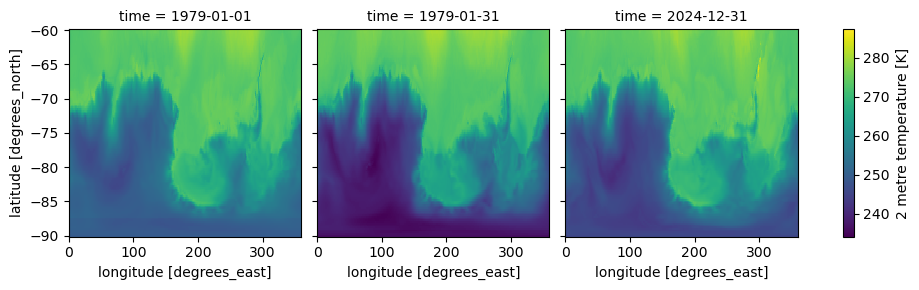

In [38]:
da.isel(time=[0, 30, -1]).sel(latitude=slice(None, -60)).plot(col='time')

In [39]:
da#.sel(latitude=slice(-90, -60))

<xarray.DataArray 'tasmax' (time: 16802, latitude: 121, longitude: 1440)> Size: 12GB
dask.array<rechunk-p2p, shape=(16802, 121, 1440), dtype=float32, chunksize=(16802, 20, 40), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 134kB 1979-01-01 1979-01-02 ... 2024-12-31
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * latitude   (latitude) float32 484B -90.0 -89.75 -89.5 ... -60.5 -60.25 -60.0
Attributes:
    units:      K
    long_name:  2 metre temperature

In [40]:
da = da.rename({'latitude': 'lat', 'longitude': 'lon'})

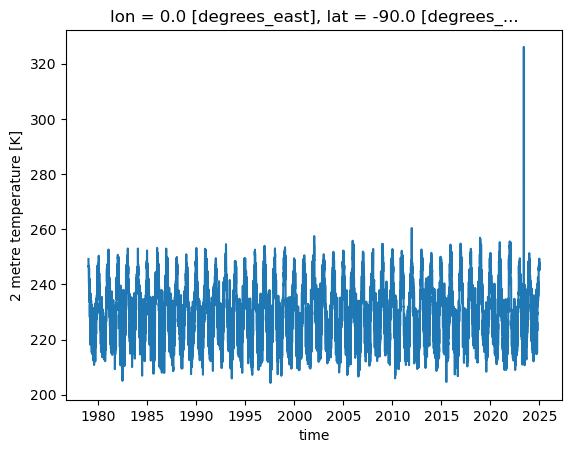

In [43]:
da.isel(lat=0, lon=0).plot()

In [44]:
from zarr.codecs import BloscCodec, BloscShuffle

compressor = BloscCodec(cname="zstd", clevel=5, shuffle=BloscShuffle.bitshuffle)

encoding = {
    "tasmax": {
        "compressors": [compressor],
        "chunks": (da.sizes["time"], 20, 40),
    }
}

In [45]:
ZARR_OUT_2 = '/work/scratch-pw4/aborow/era5_tasmax_antarctic_v2.zarr'

'/work/scratch-pw4/aborow/era5_tasmax_antarctic_v2.zarr'

In [47]:
da.to_dataset(name="tasmax").to_zarr(
    ZARR_OUT_2,
    encoding=encoding,
    consolidated=True,
    mode="w",
)

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/api/asynchronous.py:227: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [48]:
da

<xarray.DataArray 'tasmax' (time: 16802, lat: 121, lon: 1440)> Size: 12GB
dask.array<rechunk-p2p, shape=(16802, 121, 1440), dtype=float32, chunksize=(16802, 20, 40), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 134kB 1979-01-01 1979-01-02 ... 2024-12-31
  * lon      (lon) float32 6kB 0.0 0.25 0.5 0.75 1.0 ... 359.0 359.2 359.5 359.8
  * lat      (lat) float32 484B -90.0 -89.75 -89.5 -89.25 ... -60.5 -60.25 -60.0
Attributes:
    units:      K
    long_name:  2 metre temperature

### Opening

In [76]:
ZARR_OUT_2 = '/work/scratch-pw4/aborow/era5_tasmax_antarctic_v2.zarr'

In [77]:
era5_da = xr.open_zarr(ZARR_OUT_2).tasmax

In [78]:
era5_da

<xarray.DataArray 'tasmax' (time: 16802, lat: 121, lon: 1440)> Size: 12GB
dask.array<open_dataset-tasmax, shape=(16802, 121, 1440), dtype=float32, chunksize=(16802, 20, 40), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float32 6kB 0.0 0.25 0.5 0.75 1.0 ... 359.0 359.2 359.5 359.8
  * time     (time) datetime64[ns] 134kB 1979-01-01 1979-01-02 ... 2024-12-31
  * lat      (lat) float32 484B -90.0 -89.75 -89.5 -89.25 ... -60.5 -60.25 -60.0
Attributes:
    units:      K
    long_name:  2 metre temperature

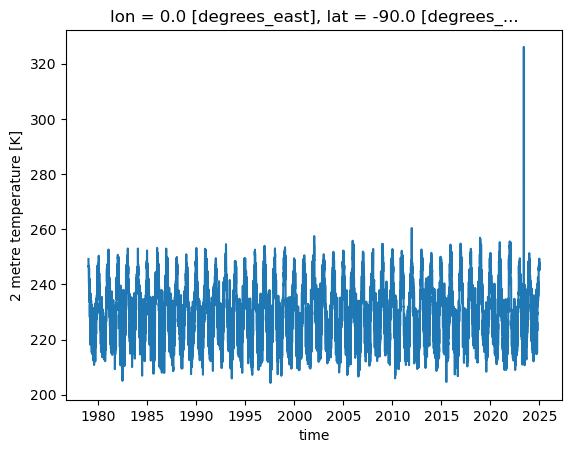

In [79]:
era5_da.isel(lat=0, lon=0).plot()

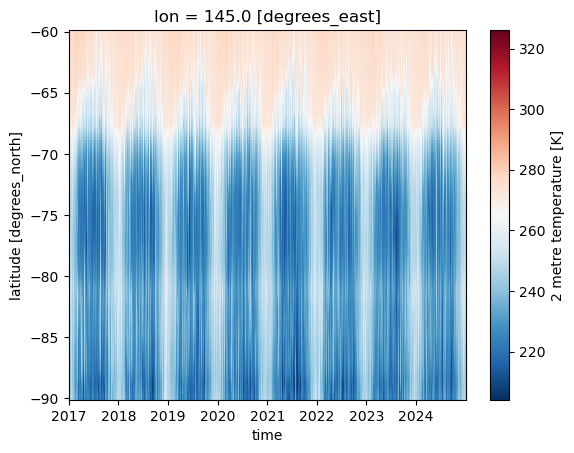

In [80]:
era5_da.sel(lat=slice(-90, -60)).sel(lon=145, method='nearest').sel(time=era5_da.time.dt.year>2016).plot(x='time', cmap='RdBu_r');

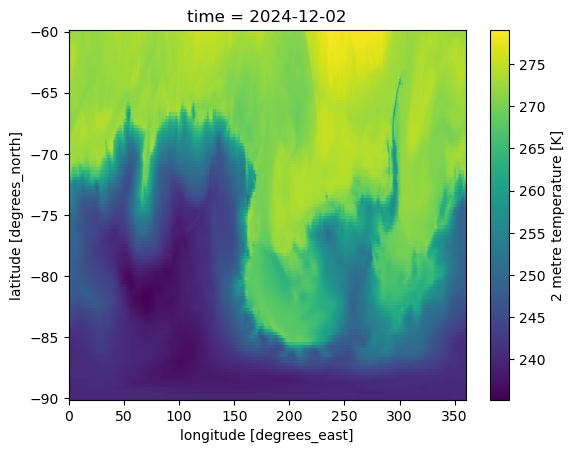

In [81]:
era5_da.isel(time=-30).plot()

## LESFMIP

### Path finding

In [75]:
os.listdir('/gws/nopw/j04')

['scenario']

In [13]:
ROOT_DIR = '/gws/ssde/j25a/extant/data'

In [14]:
potential_models = np.array(os.listdir(ROOT_DIR))
models = np.array([m for m in potential_models if os.path.isdir(os.path.join(ROOT_DIR, m))])
models

array(['ACCESS-CM2', 'ACCESS-ESM1-5', 'BCC-CSM2-MR', 'BCC-ESM1', 'CESM2',
       'CMCC-CM2-SR5', 'CNRM-CM6-1', 'CNRM-ESM2-1', 'CanESM2', 'CanESM5',
       'E3SM-1-0', 'EC-Earth3-Veg', 'EC-Earth3', 'ERA5', 'FGOALS-g3',
       'GISS-E2-1-G', 'HadGEM3-GC31-CANARI', 'HadGEM3-GC31-LL',
       'HadGEM3-GC31-MM', 'INM-CM5-0', 'IPSL-CM6A-LR', 'MIROC-ES2L',
       'MIROC6', 'MPI-ESM1-2-HR', 'MPI-ESM1-2-LR', 'MRI-ESM2-0', 'NESM3',
       'NorESM2-LM', 'RCM', 'UKESM1-0-LL', 'downloading'], dtype='<U19')

In [15]:
LESMIP_MODELS = ['ACCESS-ESM1-5',
       'CMCC-CM2-SR5', 'CNRM-CM6-1', 'CanESM5',
       'GISS-E2-1-G', 'HadGEM3-GC31-LL', 'IPSL-CM6A-LR',
       'MIROC6', 'MPI-ESM1-2-LR',
       'NorESM2-LM']

In [16]:
len(LESMIP_MODELS)

10

In [17]:
model_list_dict = defaultdict(dict)


for model in LESMIP_MODELS:
    print(model)
    model_path = os.path.join(ROOT_DIR, model, 'day')
    variables = os.listdir(model_path)
    for variable in variables:
        # print(variable)
        variable_path = os.path.join(model_path, variable)
        if os.path.isdir(variable_path): 
            glob_path = os.path.join(variable_path, '**', '*.nc')
            print(f'searching {glob_path}')
            full_paths = glob(glob_path, recursive=True)
            fnames = full_paths#list(map(os.path.basename, full_paths))
            fnames_grouped = defaultdict(list)
            for fname in fnames:
                fnames_grouped[fname.split('_')[3]].append(fname)

            model_list_dict[model][variable] = {'path': variable_path, 'fnames': fnames_grouped}

ACCESS-ESM1-5
searching /gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/pr/**/*.nc
searching /gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/psl/**/*.nc
searching /gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/tas/**/*.nc
searching /gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/tasmax/**/*.nc
searching /gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/uas/**/*.nc
searching /gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/va/**/*.nc
searching /gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/vas/**/*.nc
CMCC-CM2-SR5
searching /gws/ssde/j25a/extant/data/CMCC-CM2-SR5/day/pr/**/*.nc
searching /gws/ssde/j25a/extant/data/CMCC-CM2-SR5/day/tas/**/*.nc
searching /gws/ssde/j25a/extant/data/CMCC-CM2-SR5/day/tasmax/**/*.nc
searching /gws/ssde/j25a/extant/data/CMCC-CM2-SR5/day/va/**/*.nc
CNRM-CM6-1
searching /gws/ssde/j25a/extant/data/CNRM-CM6-1/day/psl/**/*.nc
searching /gws/ssde/j25a/extant/data/CNRM-CM6-1/day/tas/**/*.nc
searching /gws/ssde/j25a/extant/data/CNRM-CM6-1/day/tasmax/**/*.nc
searching /gws/ssde/j25a/extant/

In [18]:
model_list_dict

defaultdict(dict,
            {'ACCESS-ESM1-5': {'pr': {'path': '/gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/pr',
               'fnames': defaultdict(list, {})},
              'psl': {'path': '/gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/psl',
               'fnames': defaultdict(list, {})},
              'tas': {'path': '/gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/tas',
               'fnames': defaultdict(list, {})},
              'tasmax': {'path': '/gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/tasmax',
               'fnames': defaultdict(list, {})},
              'uas': {'path': '/gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/uas',
               'fnames': defaultdict(list,
                           {'historical': ['/gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/uas/uas_day_ACCESS-ESM1-5_historical_r10i1p1f1_gn_19500101-19991231.nc',
                             '/gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/uas/uas_day_ACCESS-ESM1-5_historical_r10i1p1f1_gn_20000101-20141231.nc',
  

In [19]:
{model: values.get('tasmax') for model, values in model_list_dict.items()}

{'ACCESS-ESM1-5': {'path': '/gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/tasmax',
  'fnames': defaultdict(list, {})},
 'CMCC-CM2-SR5': {'path': '/gws/ssde/j25a/extant/data/CMCC-CM2-SR5/day/tasmax',
  'fnames': defaultdict(list, {})},
 'CNRM-CM6-1': {'path': '/gws/ssde/j25a/extant/data/CNRM-CM6-1/day/tasmax',
  'fnames': defaultdict(list, {})},
 'CanESM5': {'path': '/gws/ssde/j25a/extant/data/CanESM5/day/tasmax',
  'fnames': defaultdict(list, {})},
 'GISS-E2-1-G': {'path': '/gws/ssde/j25a/extant/data/GISS-E2-1-G/day/tasmax',
  'fnames': defaultdict(list,
              {'hist-sol': ['/gws/ssde/j25a/extant/data/GISS-E2-1-G/day/tasmax/tasmax_day_GISS-E2-1-G_hist-sol_r6i1p1f2_gn_18500101-18991231.nc',
                '/gws/ssde/j25a/extant/data/GISS-E2-1-G/day/tasmax/tasmax_day_GISS-E2-1-G_hist-sol_r6i1p1f2_gn_19000101-19391231.nc',
                '/gws/ssde/j25a/extant/data/GISS-E2-1-G/day/tasmax/tasmax_day_GISS-E2-1-G_hist-sol_r6i1p1f2_gn_19400101-19791231.nc',
                '/gws/ssde

In [20]:
model = 'HadGEM3-GC31-LL'

In [21]:
sample_dict = model_list_dict[model]['tasmax']

In [22]:
sample_dict.keys()

dict_keys(['path', 'fnames'])

In [23]:
sample_dict['fnames'].keys()

dict_keys(['hist-GHG', 'hist-aer', 'hist-lu', 'hist-nat', 'hist-sol', 'hist-totalO3', 'hist-volc', 'historical', 'day'])

In [24]:
hist_path = sample_dict['fnames']['historical'][0]
hist_path

'/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/historical/tasmax_day_HadGEM3-GC31-LL_historical_r11i1p1f3_gn_18500101-19491230.nc'

In [25]:
hist_path_split = os.path.basename(hist_path).split('.')[0].split('_')
experiment, ensemble_member, _, time = hist_path_split[-4:]
experiment, ensemble_member, _, time

('historical', 'r11i1p1f3', 'gn', '18500101-19491230')

In [26]:
hist_match = [f for f in sample_dict['fnames']['historical'] if ((experiment in f) and (ensemble_member in f))]
hist_match

['/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/historical/tasmax_day_HadGEM3-GC31-LL_historical_r11i1p1f3_gn_18500101-19491230.nc',
 '/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/historical/tasmax_day_HadGEM3-GC31-LL_historical_r11i1p1f3_gn_19500101-20141230.nc']

In [27]:
hist_wild_path = re.sub(r'_gn_\d+-\d+\.nc$', '_gn_*.nc', hist_match[0])
hist_wild_path

'/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/historical/tasmax_day_HadGEM3-GC31-LL_historical_r11i1p1f3_gn_*.nc'

In [28]:
# hist_da = xr.open_mfdataset(hist_wild_path)

In [29]:
ensmemble_date_str = "_".join(hist_path.split('.')[0].split('_')[-3:])
ensmemble_date_str

'r11i1p1f3_gn_18500101-19491230'

In [30]:
hist_nat_path = sample_dict['fnames']['hist-nat'][0]
hist_nat_path

'/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/hist-nat/tasmax_day_HadGEM3-GC31-LL_hist-nat_r10i1p1f3_gn_18500101-19491230.nc'

In [31]:
hist_nat_wild_path = re.sub(r'_gn_\d+-\d+.nc$', '_gn_*.nc',hist_nat_path)
hist_nat_wild_path

'/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/hist-nat/tasmax_day_HadGEM3-GC31-LL_hist-nat_r10i1p1f3_gn_*.nc'

### Hist Multi Ensemble

In [32]:
import logging

In [33]:
logger = logging.getLogger(__name__)

In [34]:
def _hist_preprocess_single_member(ds: xr.Dataset) -> xr.Dataset:
    """Subset one file to tasmax over the Dome C box and label it by variant.

    Parameters
    ----------
    ds : xr.Dataset
        A single CMIP6 file as opened by ``open_mfdataset``.

    Returns
    -------
    xr.Dataset
        ``tasmax`` only, on a (member, time, lat, lon) grid, encoding stripped.
    """
    ds = (
        ds[["tasmax"]]
        .sel(lat=slice(-82, -78), lon=slice(120, 129))
        .expand_dims(member=[ds.attrs["variant_label"]])
    )
    ds.encoding.clear()
    ds.tasmax.encoding.clear()
    ds.time.encoding.clear()
    return ds

In [35]:
from IPython.display import display

In [36]:
def group_by_member(fnames: list[str]) -> dict[str, list[str]]:
    """Group file paths by the rXiYpZfW member id in their filename."""
    by_member = defaultdict(list)
    for p in fnames:
        by_member[re.search(r"_(r\d+i\d+p\d+f\d+)_", p).group(1)].append(p)
    logger.debug("grouped %d files into %d members", len(fnames), len(by_member))
    return by_member


def get_members_already_run(out: str) -> list[str]:
    """Member ids present in the Zarr store `out`; empty list if `out` does not exist."""
    if not os.path.exists(out):
        logger.debug("no store at %s", out)
        return []
    members = list(xr.open_dataset(out, engine='zarr').member.values)
    logger.debug("found %d members in %s", len(members), out)
    return members


def make_batches(
    by_member: dict[str, list[str]],
    members_already_run: list[str],
    batch_size:int=5
) -> list[list[list[str]]]:
    """File lists for the members of `by_member` not in `members_already_run`, in batches of 5."""
    nested = [sorted(f) for m, f in by_member.items() if m not in members_already_run]
    batches = [nested[i:i + batch_size] for i in range(0, len(nested), batch_size)]
    logger.debug("%d members pending -> %d batches", len(nested), len(batches))
    print(list(map(len, nested)))
    return batches


def write_batches(
    batches: list[list[list[str]]],
    out: str,
    preprocess: Callable[[xr.Dataset], xr.Dataset],
) -> None:
    """Open each batch along (member, time) and write it to `out`, appending after the first."""
    append = os.path.exists(out)
    for i, batch in enumerate(batches):
        logger.info("batch %d/%d: opening %d members", i + 1, len(batches), len(batch))
        logger.debug(batch)
        ds = xr.open_mfdataset(
            batch,
            preprocess=preprocess,
            combine='nested',
            concat_dim=['member', 'time'],
            parallel=True,
            data_vars='minimal',
            coords='minimal',
            compat='override',
            join='override',
            chunks={'time':-1}
        )
        if logger.isEnabledFor(logging.DEBUG): display(ds)

        ds = ds.load()

        ds = ds.chunk({"member": 1, "time": -1, "lat": -1, "lon": -1})
        if append:
            ds.to_zarr(out, append_dim="member")
        else:
            logger.info("creating store %s", out)
            ds.to_zarr(out, mode="w")
        logger.info("wrote batch %d/%d: %s", i + 1, len(batches), list(ds.member.values))
        ds.close()
        append = True


def save_model_by_member_batches(
    path_pattern: str,
    out: str,
    preprocess: Callable[[xr.Dataset], xr.Dataset],
    batch_size:int=5,
) -> None:
    """Save the files matching `path_pattern` to the Zarr store `out`, in batches of 5 members.

    Skips members already stored; creates the store if it does not exist.
    """
    by_member = group_by_member(sorted(glob(path_pattern)))
    members_already_run = get_members_already_run(out)
    batches = make_batches(by_member, members_already_run, batch_size)
    logger.info(
        "%s: %d members, %d already run, %d pending in %d batches",
        out, len(by_member), len(members_already_run),
        len(by_member) - len(members_already_run), len(batches),
    )
    write_batches(batches, out, preprocess)
    logger.info("finished %s", out)

In [37]:
import logging
from logger import setup_logging

logger = setup_logging(__name__, logging.DEBUG)

In [38]:
out = "/work/scratch-pw4/aborow/tasmax_hist_HadGEM3-GC31-LL_subset.zarr"

In [39]:
mf_wildcard_hist_path = '/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/historical/tasmax_day_HadGEM3-GC31-LL_historical*.nc'
# mf_wildcard_hist_path = '/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/hist-nat/tasmax_day_HadGEM3-GC31-LL_hist-nat_*.nc'

In [40]:
logger.setLevel(logging.DEBUG)

In [41]:
save_model_by_member_batches(mf_wildcard_hist_path, out, _hist_preprocess_single_member, batch_size=5)

14:56:49 DEBUG   __main__ | grouped 110 files into 55 members
14:56:51 DEBUG   __main__ | found 41 members in /work/scratch-pw4/aborow/tasmax_hist_HadGEM3-GC31-LL_subset.zarr
14:56:51 DEBUG   __main__ | 14 members pending -> 3 batches
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
14:56:51 INFO    __main__ | /work/scratch-pw4/aborow/tasmax_hist_HadGEM3-GC31-LL_subset.zarr: 55 members, 41 already run, 14 pending in 3 batches
14:56:51 INFO    __main__ | batch 1/3: opening 5 members
14:56:51 DEBUG   __main__ | [['/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/historical/tasmax_day_HadGEM3-GC31-LL_historical_r12i1p1f3_gn_18500101-19491230.nc', '/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/historical/tasmax_day_HadGEM3-GC31-LL_historical_r12i1p1f3_gn_19500101-20141230.nc'], ['/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/historical/tasmax_day_HadGEM3-GC31-LL_historical_r13i1p1f3_gn_18500101-19491230.nc', '/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/historical/t

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


<xarray.Dataset> Size: 24MB
Dimensions:  (member: 5, time: 59400, lat: 4, lon: 5)
Coordinates:
  * member   (member) object 40B 'r12i1p1f3' 'r13i1p1f3' ... 'r1i1p1f3'
  * time     (time) object 475kB 1850-01-01 12:00:00 ... 2014-12-30 12:00:00
  * lat      (lat) float64 32B -81.88 -80.62 -79.38 -78.12
  * lon      (lon) float64 40B 120.9 122.8 124.7 126.6 128.4
    height   float64 8B 1.5
Data variables:
    tasmax   (member, time, lat, lon) float32 24MB 253.9 253.9 ... 257.9 258.1
Attributes: (12/48)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  7200.0
    creation_date:          2023-05-20T05:21:43Z
    ...                     ...
    tracking_id:            hdl:21.14100/ed01b1af-9568-4d09-85c8-ffc35bd21065
    variable_id:            tasmax
    variable_name:          tasmax
    variant_label:          r12i1p1f3
    license:                CMIP6 model data produced by the Met Office Hadle...
    cmor_version:           3.7.1

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/api/asynchronous.py:227: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be suppo

14:57:37 INFO    __main__ | wrote batch 1/3: ['r12i1p1f3', 'r13i1p1f3', 'r14i1p1f3', 'r15i1p1f3', 'r1i1p1f3']
14:57:37 INFO    __main__ | batch 2/3: opening 5 members
14:57:37 DEBUG   __main__ | [['/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/historical/tasmax_day_HadGEM3-GC31-LL_historical_r2i1p1f3_gn_18500101-19491230.nc', '/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/historical/tasmax_day_HadGEM3-GC31-LL_historical_r2i1p1f3_gn_19500101-20141230.nc'], ['/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/historical/tasmax_day_HadGEM3-GC31-LL_historical_r3i1p1f3_gn_18500101-19491230.nc', '/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/historical/tasmax_day_HadGEM3-GC31-LL_historical_r3i1p1f3_gn_19500101-20141230.nc'], ['/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/historical/tasmax_day_HadGEM3-GC31-LL_historical_r4i1p1f3_gn_18500101-19491230.nc', '/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/historical/tasmax_day_HadGEM3-GC31-LL_historical_

...

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be suppor

14:58:22 INFO    __main__ | wrote batch 2/3: ['r2i1p1f3', 'r3i1p1f3', 'r4i1p1f3', 'r56i1p1f3', 'r57i1p1f3']
14:58:22 INFO    __main__ | batch 3/3: opening 4 members
14:58:22 DEBUG   __main__ | [['/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/historical/tasmax_day_HadGEM3-GC31-LL_historical_r58i1p1f3_gn_18500101-19491230.nc', '/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/historical/tasmax_day_HadGEM3-GC31-LL_historical_r58i1p1f3_gn_19500101-20141230.nc'], ['/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/historical/tasmax_day_HadGEM3-GC31-LL_historical_r59i1p1f3_gn_18500101-19491230.nc', '/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/historical/tasmax_day_HadGEM3-GC31-LL_historical_r59i1p1f3_gn_19500101-20141230.nc'], ['/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/historical/tasmax_day_HadGEM3-GC31-LL_historical_r5i1p1f3_gn_18500101-19491230.nc', '/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/historical/tasmax_day_HadGEM3-GC31-LL_historica

<xarray.Dataset> Size: 19MB
Dimensions:  (member: 4, time: 59400, lat: 4, lon: 5)
Coordinates:
  * member   (member) object 32B 'r58i1p1f3' 'r59i1p1f3' 'r5i1p1f3' 'r60i1p1f3'
  * time     (time) object 475kB 1850-01-01 12:00:00 ... 2014-12-30 12:00:00
  * lat      (lat) float64 32B -81.88 -80.62 -79.38 -78.12
  * lon      (lon) float64 40B 120.9 122.8 124.7 126.6 128.4
    height   float64 8B 1.5
Data variables:
    tasmax   (member, time, lat, lon) float32 19MB 255.8 256.0 ... 257.4 257.7
Attributes: (12/48)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  172800.0
    creation_date:          2023-06-28T12:07:22Z
    ...                     ...
    tracking_id:            hdl:21.14100/29606c96-06ad-4a0d-b627-bb6812ab087a
    variable_id:            tasmax
    variable_name:          tasmax
    variant_label:          r58i1p1f3
    license:                CMIP6 model data produced by the Met Office Hadle...
    cmor_version:           3.7.1

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be suppor

14:59:05 INFO    __main__ | wrote batch 3/3: ['r58i1p1f3', 'r59i1p1f3', 'r5i1p1f3', 'r60i1p1f3']
14:59:05 INFO    __main__ | finished /work/scratch-pw4/aborow/tasmax_hist_HadGEM3-GC31-LL_subset.zarr


In [163]:
hist_ensemble_ds = xr.open_dataset(out, engine='zarr', chunks={'time':-1, 'member':11, 'lat':-1, 'lon':-1}).tasmax.compute()

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


In [ ]:
# hist_ensemble_ds.isel(lat=0, lon=0).plot(x='time', hue='member', add_legend=False);

#### Old

In [28]:
model = 'HadGEM3-GC31-LL'

Opening all of the ensemble members for historical simulation for HadGEM3-GC31-LL. This is is currently subsetted to just a few locations in order to prototype.

In [29]:
mf_wildcard_hist_path = '/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/historical/tasmax_day_HadGEM3-GC31-LL_historical*.nc'
mf_wildcard_hist_path = '/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/hist-nat/tasmax_day_HadGEM3-GC31-LL_hist-nat_*.nc'

In [30]:
by_member = defaultdict(list)
for p in sample_dict['fnames']['historical']:
    by_member[re.search(r"_(r\d+i\d+p\d+f\d+)_", p).group(1)].append(p)

members = sorted(by_member, key=lambda s: int(re.match(r"r(\d+)", s).group(1)))

In [31]:
out = "/work/scratch-pw4/aborow/tasmax_hist_HadGEM3-GC31-LL_subset.zarr"

In [32]:
if os.path.exists(out):
    print('File already exists')
    members_already_run = xr.open_dataset(out, engine='zarr').member.values

File already exists


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


In [33]:
members_already_run

array(['r16i1p1f3', 'r17i1p1f3', 'r18i1p1f3', 'r19i1p1f3', 'r20i1p1f3',
       'r21i1p1f3', 'r22i1p1f3', 'r23i1p1f3', 'r24i1p1f3', 'r25i1p1f3',
       'r26i1p1f3', 'r27i1p1f3', 'r28i1p1f3', 'r29i1p1f3', 'r30i1p1f3',
       'r31i1p1f3', 'r32i1p1f3', 'r33i1p1f3', 'r34i1p1f3', 'r35i1p1f3',
       'r36i1p1f3', 'r37i1p1f3', 'r38i1p1f3', 'r39i1p1f3', 'r40i1p1f3',
       'r41i1p1f3', 'r42i1p1f3', 'r43i1p1f3', 'r44i1p1f3', 'r45i1p1f3',
       'r46i1p1f3', 'r47i1p1f3', 'r48i1p1f3', 'r49i1p1f3', 'r50i1p1f3',
       'r51i1p1f3', 'r52i1p1f3', 'r53i1p1f3', 'r54i1p1f3', 'r55i1p1f3'],
      dtype=object)

In [34]:
nested = [sorted(by_member[m]) for m in members if m not in members_already_run]
batches = [nested[i:i + 5] for i in range(0, len(nested), 5)]

print(f'Alread run: {len(members_already_run)}\nRemaining: {len(nested)}.\n{len(batches)} batches left to go')

Alread run: 40
Remaining: 15.
3 batches left to go


In [83]:
list(map(len, nested))

[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]

In [81]:
batches

[[['/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/historical/tasmax_day_HadGEM3-GC31-LL_historical_r1i1p1f3_gn_18500101-19491230.nc',
   '/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/historical/tasmax_day_HadGEM3-GC31-LL_historical_r1i1p1f3_gn_19500101-20141230.nc'],
  ['/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/historical/tasmax_day_HadGEM3-GC31-LL_historical_r2i1p1f3_gn_18500101-19491230.nc',
   '/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/historical/tasmax_day_HadGEM3-GC31-LL_historical_r2i1p1f3_gn_19500101-20141230.nc'],
  ['/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/historical/tasmax_day_HadGEM3-GC31-LL_historical_r3i1p1f3_gn_18500101-19491230.nc',
   '/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/historical/tasmax_day_HadGEM3-GC31-LL_historical_r3i1p1f3_gn_19500101-20141230.nc'],
  ['/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/historical/tasmax_day_HadGEM3-GC31-LL_historical_r4i1p1f3_gn_18500101-19491230.nc',
   

In [80]:
list(map(len, batches))

[5, 5, 5]

In [42]:
for i, batch in enumerate(batches):
    ds = xr.open_mfdataset(
        batch,
        preprocess=_hist_preprocess_single_member,
        combine='nested',
        concat_dim=['member', 'time'],
        parallel=True,
        data_vars='minimal',
        coords='minimal',
        compat='override',
        join='override',
        chunks={'time': -1},

    )

    break
    

In [43]:
ds

<xarray.Dataset> Size: 24MB
Dimensions:  (member: 5, time: 59400, lat: 4, lon: 5)
Coordinates:
  * member   (member) object 40B 'r1i1p1f3' 'r2i1p1f3' ... 'r4i1p1f3' 'r5i1p1f3'
  * time     (time) object 475kB 1850-01-01 12:00:00 ... 2014-12-30 12:00:00
  * lat      (lat) float64 32B -81.88 -80.62 -79.38 -78.12
  * lon      (lon) float64 40B 120.9 122.8 124.7 126.6 128.4
    height   float64 8B ...
Data variables:
    tasmax   (member, time, lat, lon) float32 24MB dask.array<chunksize=(1, 36000, 4, 5), meta=np.ndarray>
Attributes: (12/46)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  0.0
    creation_date:          2019-06-19T14:20:08Z
    ...                     ...
    title:                  HadGEM3-GC31-LL output prepared for CMIP6
    variable_id:            tasmax
    variant_label:          r1i1p1f3
    license:                CMIP6 model data produced by the Met Office Hadle...
    cmor_version:           3.4.0
    tracking_id:            hdl:21.14100/ce656162-9898-47ca-be4f-ef0dec151bfc

In [44]:
out

'/work/scratch-pw4/aborow/tasmax_hist_HadGEM3-GC31-LL_subset.zarr'

In [45]:
%time
ds.load()

CPU times: user 4 μs, sys: 0 ns, total: 4 μs
Wall time: 6.2 μs


<xarray.Dataset> Size: 24MB
Dimensions:  (member: 5, time: 59400, lat: 4, lon: 5)
Coordinates:
  * member   (member) object 40B 'r1i1p1f3' 'r2i1p1f3' ... 'r4i1p1f3' 'r5i1p1f3'
  * time     (time) object 475kB 1850-01-01 12:00:00 ... 2014-12-30 12:00:00
  * lat      (lat) float64 32B -81.88 -80.62 -79.38 -78.12
  * lon      (lon) float64 40B 120.9 122.8 124.7 126.6 128.4
    height   float64 8B 1.5
Data variables:
    tasmax   (member, time, lat, lon) float32 24MB 256.7 257.1 ... 256.4 257.0
Attributes: (12/46)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  0.0
    creation_date:          2019-06-19T14:20:08Z
    ...                     ...
    title:                  HadGEM3-GC31-LL output prepared for CMIP6
    variable_id:            tasmax
    variant_label:          r1i1p1f3
    license:                CMIP6 model data produced by the Met Office Hadle...
    cmor_version:           3.4.0
    tracking_id:            hdl:21.14100/ce656162-9898-47ca-be4f-ef0dec151bfc

In [88]:
for i, batch in enumerate(batches):
    ds = xr.open_mfdataset(
        batch,
        preprocess=_hist_preprocess_single_member,
        combine='nested',
        concat_dim=['member', 'time'],
        parallel=True,
        data_vars='minimal',
        coords='minimal',
        compat='override',
        join='override',
    ).load()

    ds = ds.chunk({"member": 1, "time": -1, "lat": -1, "lon": -1})
        
    if os.path.exists(out):
        ds.to_zarr(out, append_dim="member")
    else:
        ds.to_zarr(out, mode="w")

    print(f"{i + 1}/{len(batches)}: {list(ds.member.values)}")
    ds.close()

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 74.05 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
def _hist_preprocess_single_member(ds):
    return (
        ds[["tasmax"]]
        .sel(lat=slice(-82, -78), lon=slice(120, 129))
        .expand_dims(member=[ds.attrs["variant_label"]])
    )

In [ ]:
%time

hist_ensemble_ds = xr.open_mfdataset(
    nested,
    preprocess=_hist_preprocess_single_member,
    combine='nested',
    concat_dim=['member', 'time'],
    parallel=True,
    data_vars='minimal',
    coords='minimal',
    compat='override',
    join='override'
).chunk({"time": -1})

In [ ]:
# hist_ensemble_ds = hist_ensemble_ds.tasmax

In [ ]:
hist_ensemble_ds = hist_ensemble_ds.tasmax

In [ ]:
hist_ensemble_ds

In [ ]:
ds = hist_ensemble_ds.chunk({"member": 1, "time": -1, "lat": -1, "lon": -1})

In [ ]:
ds.encoding#.clear()

In [49]:
ds

<xarray.DataArray 'tasmax' (member: 55, time: 59400, lat: 4, lon: 5)> Size: 261MB
dask.array<rechunk-merge, shape=(55, 59400, 4, 5), dtype=float32, chunksize=(1, 59400, 4, 5), chunktype=numpy.ndarray>
Coordinates:
  * member   (member) object 440B 'r1i1p1f3' 'r2i1p1f3' ... 'r60i1p1f3'
  * time     (time) object 475kB 1850-01-01 12:00:00 ... 2014-12-30 12:00:00
  * lat      (lat) float64 32B -81.88 -80.62 -79.38 -78.12
  * lon      (lon) float64 40B 120.9 122.8 124.7 126.6 128.4
    height   float64 8B ...
Attributes:
    standard_name:  air_temperature
    long_name:      Daily Maximum Near-Surface Air Temperature
    comment:        maximum near-surface (usually, 2 meter) air temperature (...
    units:          K
    original_name:  mo: (stash: m01s03i236, lbproc: 8192)
    cell_methods:   area: mean time: maximum
    cell_measures:  area: areacella
    history:        2019-06-19T14:20:08Z altered by CMOR: Treated scalar dime...

In [47]:
ds = ds.compute()

ClosedClientError: Client is closed. Can't send update-graph message.

In [44]:
ds.to_zarr(out, mode="w")

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/core/array.py:4275: UserWarning: The dtype `StringDType()` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  meta = AsyncArray._create_metadata_v3(
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be su

FutureCancelledError: finalize-hlgfinalizecompute-a2efb17a87ee41c48bfe5b771f603c92 cancelled for reason: scheduler-connection-lost.
Client lost the connection to the scheduler. Please check your connection and re-run your work.

In [ ]:
hist_ensemble_ds = xr.open_dataset(out, engine='zarr')

In [ ]:
hist_ensemble_ds

In [ ]:
hist_ensemble_ds.isel(lat=0, lon=0).plot()

### Opening Models

In [39]:
hist_ds = xr.open_mfdataset(
    hist_wild_path,
    chunks={'time': 3650, 'lat': -1, 'lon': -1},
    parallel=True,
).sel(lat=slice(-90, -60)).tasmax

In [52]:
hist_nat_ds = xr.open_mfdataset(
    hist_nat_path,
    chunks={'time': 3650, 'lat': -1, 'lon': -1},
    parallel=True,
).sel(lat=slice(-90, -60)).chunk({'time': -1, 'lat': -1, 'lon': -1}).tasmax

In [143]:
hist_ds

<xarray.DataArray 'tasmax' (time: 59400, lat: 24, lon: 192)> Size: 1GB
dask.array<where, shape=(59400, 24, 192), dtype=float32, chunksize=(3650, 24, 192), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 475kB 1850-01-01 12:00:00 ... 2014-12-30 12:00:00
  * lat      (lat) float64 192B -89.38 -88.12 -86.88 ... -63.12 -61.88 -60.62
  * lon      (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
    height   float64 8B 1.5
    type     |S4 4B ...
Attributes:
    standard_name:  air_temperature
    long_name:      Daily Maximum Near-Surface Air Temperature
    comment:        maximum near-surface (usually, 2 meter) air temperature (...
    units:          K
    original_name:  mo: (stash: m01s03i236, lbproc: 8192)
    cell_methods:   area: mean time: maximum
    cell_measures:  area: areacella
    history:        2023-05-16T18:37:57Z altered by CMOR: Treated scalar dime...

In [45]:
LANDSEA_DIR = '/badc/cmip6/data/CMIP6/CMIP/MOHC/HadGEM3-GC31-LL/piControl/r1i1p1f1/fx/sftlf/gn/latest/'

In [46]:
os.listdir(LANDSEA_DIR)

['sftlf_fx_HadGEM3-GC31-LL_piControl_r1i1p1f1_gn.nc']

In [50]:
landsea_mask_ds = xr.open_dataset(os.path.join(LANDSEA_DIR, 'sftlf_fx_HadGEM3-GC31-LL_piControl_r1i1p1f1_gn.nc')).sftlf
landsea_mask_ds

<xarray.DataArray 'sftlf' (lat: 144, lon: 192)> Size: 111kB
[27648 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 1kB -89.38 -88.12 -86.88 -85.62 ... 86.88 88.12 89.38
  * lon      (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
    type     |S4 4B ...
Attributes:
    standard_name:   land_area_fraction
    long_name:       Percentage of the grid  cell occupied by land (including...
    comment:         Please express 'X_area_fraction' as the percentage of ho...
    units:           %
    original_name:   mo: (stash: m01s00i505)
    original_units:  1
    history:         2019-07-08T15:34:25Z altered by CMOR: Converted units fr...
    cell_methods:    area: mean
    cell_measures:   area: areacella

In [57]:
hist_nat_ds = hist_nat_ds.where(landsea_mask_ds)#.isel(time=-1).plot()
hist_ds = hist_ds.where(landsea_mask_ds)

# Daily Statistics

## Data set up

In [ ]:
era5_da = era5_da.convert_calendar("360_day", align_on="year")

In [262]:
era5_da = era5_da - 273.15
hist_ensemble_ds = hist_ensemble_ds - 273.15

In [263]:
latlon = dict(lat=-81.88, lon=120.9, method='nearest')

In [264]:
era5_loc = era5_da.sel(**latlon)

In [265]:
np.take(era5_loc.time.dt.year.values, [0, -1])

array([1979, 2024])

In [266]:
np.take(hist_ensemble_ds.time.dt.year.values, [0, -1])

array([1979, 2014])

In [267]:
start = 1979; end = 2014

In [268]:
hist_ensemble_ds = hist_ensemble_ds.sel(time=hist_ensemble_ds['time.year'] >= start)
era5_loc = era5_loc.sel(time=era5_loc['time.year'] <= end).compute()

In [269]:
era5_loc

<xarray.DataArray 'tasmax' (time: 12960)> Size: 52kB
array([-21.258911, -23.163315, -23.673233, ..., -27.48256 , -28.187317,
       -28.389465], shape=(12960,), dtype=float32)
Coordinates:
    lon      float32 4B 121.0
    lat      float32 4B -82.0
  * time     (time) object 104kB 1979-01-01 00:00:00 ... 2014-12-30 00:00:00

In [270]:
hist_ensemble_ds

<xarray.DataArray 'tasmax' (member: 55, time: 12960, lat: 4, lon: 5)> Size: 57MB
dask.array<getitem, shape=(55, 12960, 4, 5), dtype=float32, chunksize=(1, 12960, 4, 5), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 104kB 1979-01-01 12:00:00 ... 2014-12-30 12:00:00
  * member   (member) object 440B 'r16i1p1f3' 'r17i1p1f3' ... 'r60i1p1f3'
  * lat      (lat) float64 32B -81.88 -80.62 -79.38 -78.12
  * lon      (lon) float64 40B 120.9 122.8 124.7 126.6 128.4
    height   float64 8B 1.5

## Plume Plots

In [271]:
def plot_plume(da, pairs, median=0.5, color="C0", alpha=0.35, lw=1.8,
               figsize=(9, 4.5), x_dim="time", quantile_dim="quantile"):
    """Make a figure with quantile bands and the median line.

    da : xr.DataArray, has `quantile_dim` and `x_dim`
    pairs : Sequence[tuple[float, float]], (lower, upper) quantile labels,
        drawn in the order given — pass widest first
    median : float, quantile label drawn as a line
    color : str, applied to bands and line
    alpha : float, per-band alpha; overlapping bands compound
    lw : float, median line width; bands use lw=0

    Returns (Figure, Axes).
    """
    fig, ax = plt.subplots(figsize=figsize, layout="constrained")
    x = da[x_dim].values
    for lo, hi in pairs:
        ax.fill_between(x, da.sel({quantile_dim: lo}).values,
                        da.sel({quantile_dim: hi}).values,
                        color=color, alpha=alpha, lw=0)
    ax.plot(x, da.sel({quantile_dim: median}).values, color=color, lw=lw)
    ax.margins(x=0)
    return fig, ax

In [272]:
quantiles = np.arange(0, 1.05, 0.05)
n = len(quantiles)//2
quantile_pairs = np.column_stack([quantiles[:n], quantiles[::-1][:n]])
quantile_pairs

array([[0.  , 1.  ],
       [0.05, 0.95],
       [0.1 , 0.9 ],
       [0.15, 0.85],
       [0.2 , 0.8 ],
       [0.25, 0.75],
       [0.3 , 0.7 ],
       [0.35, 0.65],
       [0.4 , 0.6 ],
       [0.45, 0.55]])

In [273]:
hist_member_quantiles = hist_ensemble_ds.quantile(quantiles, dim=['member'])
# era5_member_quantiles = era5_loc.quantile(quantiles, dim=['member'])

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 54.40 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 54.40 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


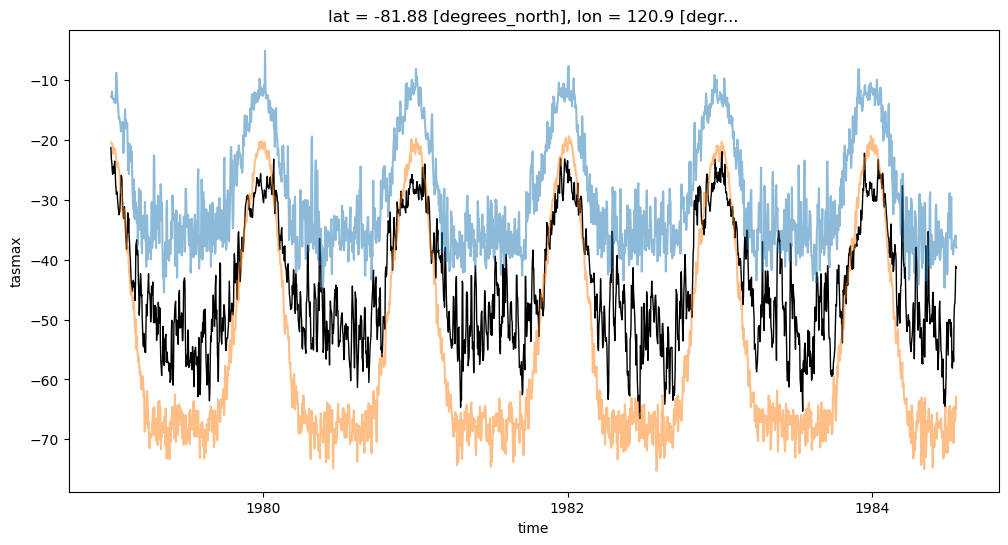

In [274]:
time_slice = slice(0, 2000)

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
era5_loc.isel(time=time_slice).plot(ax=ax, linewidth=1, color='k')
hist_ensemble_ds.isel(lat=0, lon=0).isel(time=time_slice).max(dim='member').plot(alpha=0.5)
hist_ensemble_ds.isel(lat=0, lon=0).isel(time=time_slice).min(dim='member').plot(alpha=0.5)

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 54.39 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


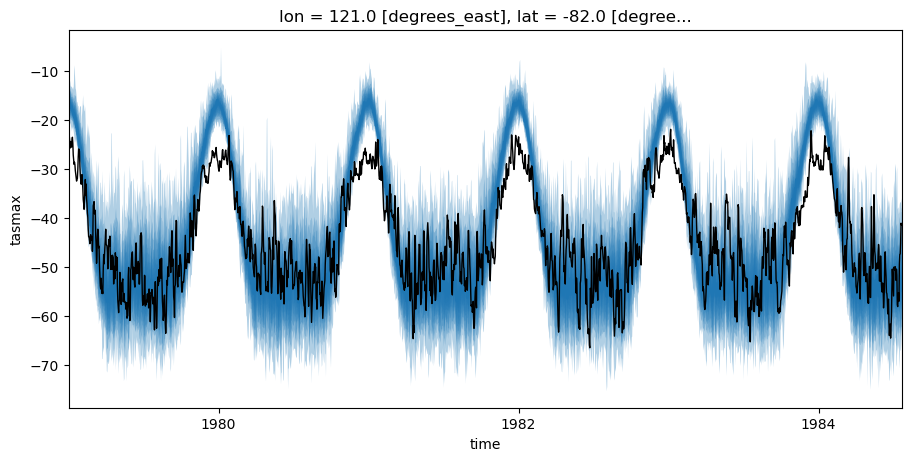

In [275]:
time_slice = slice(0, 2000)
fig, ax = plot_plume(hist_member_quantiles.isel(lat=0, lon=0, time=time_slice), quantile_pairs)
era5_loc.isel(time=time_slice).plot(ax=ax, linewidth=1, color='k')

<b> Interpretation <b>

- During Austral winter the observations is within the range of the mdoel spread
- During Austral summer, however, the model is much too hot. The observations is below the minimum of the ensemble range.
- The Austral summer median appears to be ~10degC too hot.
- This suggest that the seasonal cycyle is too strong (variability is too large)

## Quantiles and distributions

In [276]:
quantiles = np.arange(0.01, 1, 0.01)
hist_ensemble_quantiles = hist_ensemble_ds.quantile(quantiles, dim=['time', 'member'])
hist_quantiles = hist_ensemble_ds.quantile(quantiles, dim=['time'])
# 
era5_loc_quantiles = era5_loc.quantile(quantiles, dim=['time'])

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 54.40 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


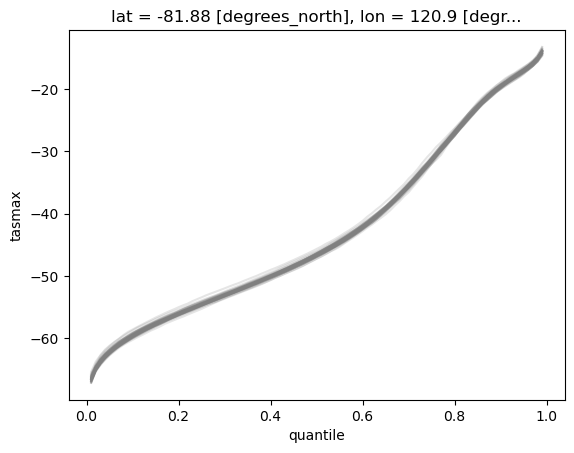

In [277]:
hist_quantiles.isel(lat=0, lon=0).plot(label='hist ind', x='quantile', hue='member', color='grey', alpha=0.2, add_legend=False);

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 54.39 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


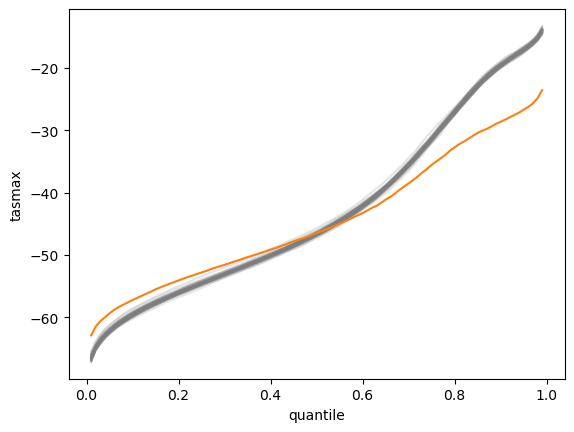

In [278]:
hist_ensemble_quantiles.isel(lat=0, lon=0).plot(label='hist')
hist_quantiles.isel(lat=0, lon=0).plot(label='hist ind', x='quantile', hue='member', color='grey', alpha=0.2, add_legend=False);
era5_loc_quantiles.plot(label='ERA5')
# plt.legend()

In [279]:
import numpy as np
from scipy.stats import gaussian_kde


def kde_axis(vmin: float, vmax: float, n: int) -> np.ndarray:
    """Evaluation points for a KDE.

    vmin, vmax : float
        Bounds of the axis, in data units.
    n : int
        Number of points.

    Returns
    -------
    np.ndarray, shape (n,)
    """
    return np.linspace(vmin, vmax, n)


def kde(samples: np.ndarray, x: np.ndarray, bw_method=None) -> np.ndarray:
    """Gaussian KDE of `samples` evaluated at `x`.

    samples : np.ndarray, shape (m,)
        1-D sample array.
    x : np.ndarray, shape (n,)
        Evaluation points, e.g. from `kde_axis`.
    bw_method : str | float | callable | None
        Passed straight to scipy.stats.gaussian_kde.

    Returns
    -------
    np.ndarray, shape (n,)
        Density at each point of `x`.
    """
    return gaussian_kde(samples, bw_method=bw_method)(x)

In [280]:
hist_ensemble_ds.min().values, hist_ensemble_ds.max().values

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 54.39 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 54.39 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


(array(-81.70932, dtype=float32), array(-3.1180115, dtype=float32))

In [281]:
hist_ensemble_ds = hist_ensemble_ds.chunk({'member':1})

In [282]:
hist_ensemble_ds

<xarray.DataArray 'tasmax' (member: 55, time: 12960, lat: 4, lon: 5)> Size: 57MB
dask.array<getitem, shape=(55, 12960, 4, 5), dtype=float32, chunksize=(1, 12960, 4, 5), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 104kB 1979-01-01 12:00:00 ... 2014-12-30 12:00:00
  * member   (member) object 440B 'r16i1p1f3' 'r17i1p1f3' ... 'r60i1p1f3'
  * lat      (lat) float64 32B -81.88 -80.62 -79.38 -78.12
  * lon      (lon) float64 40B 120.9 122.8 124.7 126.6 128.4
    height   float64 8B 1.5

In [287]:
x = np.linspace(191, 271, 200) - 273.15

dens = xr.apply_ufunc(
    lambda s: gaussian_kde(s)(x),
    hist_ensemble_ds,
    input_core_dims=[["time"]],
    output_core_dims=[["x"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float],
    dask_gufunc_kwargs={"output_sizes": {"x": x.size}},
).assign_coords(x=x)

In [288]:
era5_kde = gaussian_kde(era5_loc.values)(x)

In [289]:
dens = dens.compute()

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 54.39 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


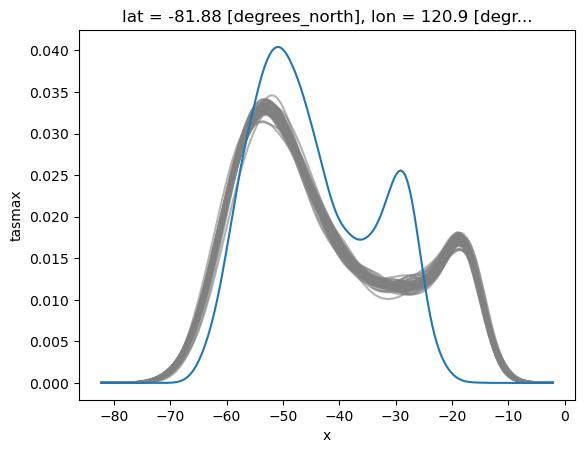

In [290]:
fig, ax = plt.subplots(1,1)
dens.isel(lat=0, lon=0).plot(ax=ax, hue='member', x='x', add_legend=False, color='grey', alpha=0.6);
ax.plot(x, era5_kde)

<b> Interprtation
- The distribution is bi-model for both models
- There are a lot more values above -20degC for the model than ERA5
- The model also has a lot more value below -75degC
- Summertime peak is in the wrong place

## Rank Histograms

Using the method from Suarez‑Gutierrez et al., 2021 that uses rank histograms to analyse if both the signal and the nosie are correct in the model. This can get you if the forced resonse is under or overestimated, and if the variable is under or overestimated

Method
1. Convert to seasonal mean.
2. Convert to anomalies: subtract the mean of all data
3. Rank the data per time step against the ensemble members
4. Do the same for each ensemble member against all the other members
5. Calculate the 5th and 95th percentiles for each bin from the ensemble member ranks
6. Compare the rank histogram for the observations against the 5th and 9th percentiles

<b> Dataset information </b>
<br>
The time ranges from 1979 to 2014. This is not many data points. As such I have used the monthly mean, using Dec, Jan and Feb to increase sample sizes.

In [304]:
xr.set_options(display_expand_data=False, display_expand_attrs=False, display_expand_data_vars=False)

In [400]:
# era5_loc_seasonal = era5_loc.resample(time='QS-DEC').mean()
era5_loc_seasonal = era5_loc.resample(time='ME').mean()
# era5_loc_seasonal = era5_loc_seasonal.sel(time=era5_loc_seasonal['time.month']==12).isel(time=slice(1, -1))
era5_loc_seasonal = era5_loc_seasonal.where(era5_loc_seasonal.time.dt.month.isin([12, 1, 2]), drop=True).isel(time=slice(1, -1))

In [407]:
hist_ensemble_seasonal_ds = hist_ensemble_ds.resample(time='ME').mean().compute()
# hist_ensemble_seasonal_ds = hist_ensemble_seasonal_ds.sel(time=hist_ensemble_seasonal_ds['time.month']==12).isel(time=slice(1, -1))
hist_ensemble_seasonal_ds = hist_ensemble_seasonal_ds.where(hist_ensemble_seasonal_ds.time.dt.month.isin([12, 1, 2]), drop=True).isel(time=slice(1, -1))

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 54.49 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [408]:
era5_loc_seasonal_anom = era5_loc_seasonal - era5_loc_seasonal.mean(dim='time')
hist_ensemble_seasonal_anom = hist_ensemble_seasonal_ds - hist_ensemble_seasonal_ds.mean(dim='time')

In [432]:
# hist_ensemble_seasonal_anom.isel(lat=0, lon=0).min(dim='member').plot(color='blue', label='ensemble min')
# hist_ensemble_seasonal_anom.isel(lat=0, lon=0).max(dim='member').plot(color='red', label='ensemble max')
# era5_loc_seasonal_anom.plot(color='k', label='ERA5')
# plt.legend()

In [411]:
era5_rank_ds = (hist_ensemble_seasonal_anom.isel(lat=0, lon=0) < era5_loc_seasonal_anom).sum(dim='member')

In [433]:
# Ranks of ERA5
# era5_rank_ds.plot()

In [413]:
ensemble_memebers = hist_ensemble_seasonal_anom.member.values
member_pseudo_ranks = []
for member in ensemble_memebers:
    other_members = [m for m in ensemble_memebers if m != member]
    other_members_ds = hist_ensemble_seasonal_anom.sel(member=other_members)
    one_member_ds = hist_ensemble_seasonal_anom.sel(member=member)
    member_rank = (other_members_ds<one_member_ds).sum(dim='member')
    member_rank  = member_rank.assign_coords(member=member)
    member_pseudo_ranks.append(member_rank)
    
member_pseudo_ranks_ds = xr.concat(member_pseudo_ranks, dim='member')

In [414]:
member_pseudo_ranks_ds

<xarray.DataArray 'tasmax' (member: 55, time: 106, lat: 4, lon: 5)> Size: 933kB
16 16 16 18 19 11 12 12 12 15 10 10 10 ... 29 30 24 25 26 27 27 24 26 24 23 23
Coordinates:
  * lat      (lat) float64 32B -81.88 -80.62 -79.38 -78.12
  * lon      (lon) float64 40B 120.9 122.8 124.7 126.6 128.4
    height   float64 8B 1.5
  * time     (time) object 848B 1979-02-30 00:00:00 ... 2014-02-30 00:00:00
  * member   (member) <U9 2kB 'r16i1p1f3' 'r17i1p1f3' ... 'r5i1p1f3' 'r60i1p1f3'

In [415]:
from xhistogram.xarray import histogram

In [416]:
bins = np.arange(0, 55)

In [417]:
era5_rank_hist = histogram(era5_rank_ds, bins=bins)

In [418]:
pseudo_histogram = histogram(member_pseudo_ranks_ds, bins=bins, dim=['time'])
pseudo_histogram_lower_upper = pseudo_histogram.quantile([0.05, 0.95], dim='member')

In [419]:
pseudo_histogram

<xarray.DataArray 'histogram_tasmax' (member: 55, lat: 4, lon: 5, tasmax_bin: 54)> Size: 475kB
1 4 3 4 0 1 2 3 2 0 4 2 2 4 3 0 3 1 0 ... 2 3 2 3 3 2 0 4 0 3 0 4 2 0 2 0 3 0 4
Coordinates:
  * member      (member) <U9 2kB 'r16i1p1f3' 'r17i1p1f3' ... 'r60i1p1f3'
  * lat         (lat) float64 32B -81.88 -80.62 -79.38 -78.12
  * lon         (lon) float64 40B 120.9 122.8 124.7 126.6 128.4
  * tasmax_bin  (tasmax_bin) float64 432B 0.5 1.5 2.5 3.5 ... 51.5 52.5 53.5

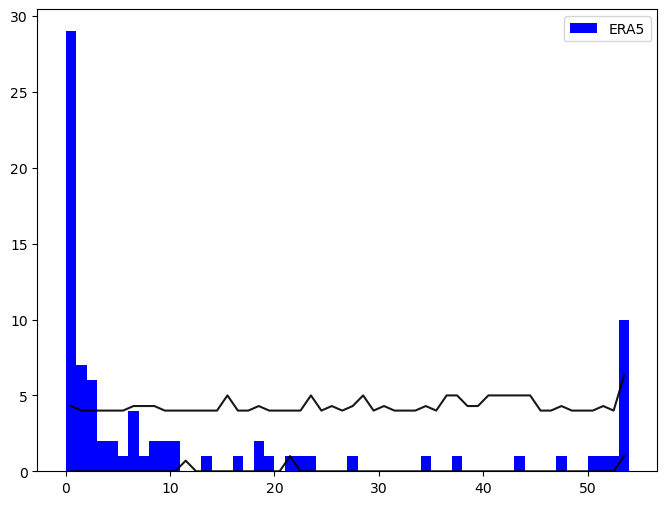

In [429]:
fig = plt.figure(figsize=(8, 6))
lower = pseudo_histogram_lower_upper.isel(lat=0, lon=0, quantile=0)
upper = pseudo_histogram_lower_upper.isel(lat=0, lon=0, quantile=1)

plt.bar(era5_rank_hist.tasmax_bin, era5_rank_hist, width=1.0, label='ERA5', color='blue')
plt.plot(lower.tasmax_bin, lower, alpha=0.9, color="k")
plt.plot(lower.tasmax_bin, upper, alpha=0.9, color="k")

plt.legend()

<b> Interpretation </b>
<br>
This looks like the model underestimates the forced resonse as the ranks are all low.

<img src="suarez.PNG" width=500 />

# Trends and S/N Ratio

## Functions

<b> Infomation </b>

- Trends are for Austral Spring 2000 to 2024
- Seasonal maximum of TAS

<b> Signal-to-noise ratio calculation </b>
- Signal here (S) is change in temperature estimated using a linear trend fit: gradeint x number of years
- Noise (N) is the standard deviation of the data after removing the linear trend
- S/N = S/N

In [40]:
from matplotlib.gridspec import GridSpec

In [41]:
def grid_slope(da, dim='time'):
    """Per-cell OLS slope of y = a + b*x.

    Closed-form normal-equation solution:

        b   = Sxy / Sxx
        Sxx = sum((x - xbar)^2)          spread of the time axis
        Sxy = sum((x - xbar)(y - ybar))  covariation of y with time

    Vectorised over all non-`dim` dimensions, so no per-cell loop.
    Time is converted to float years, since cftime objects don't support
    the arithmetic. Assumes one value per year — sub-annual data collapses
    Sxx, as every point within a year shares the same x.

    Parameters
    ----------
    da : xr.DataArray
        Input with cftime/datetime `dim`; other dims treated as cells.
    dim : str
        Dimension to regress along.

    Returns
    -------
    xr.DataArray
        Slope of the data.
    """
    x = xr.DataArray(np.arange(da.sizes[dim], dtype=float), dims=dim)

    dx = x - x.mean(dim)
    slope = (dx * (da - da.mean(dim))).sum(dim) / (dx ** 2).sum(dim)
    # slope.attrs['units'] = f"{da.attrs.get('units', '')} yr-1".strip()
    return slope

In [42]:
import numpy as np
import xarray as xr
from scipy.stats import norm


def mk_S(y, i, j):
    """Mann-Kendall S statistic along the last axis.

    S = sum_{k<l} sign(y_l - y_k), as a broadcast pairwise difference
    over precomputed upper-triangle index pairs.

    Parameters
    ----------
    y : np.ndarray
        Shape (..., n); leading axes treated as independent cells.
    i, j : np.ndarray
        Upper-triangle index pairs from np.triu_indices(n, k=1).

    Returns
    -------
    np.ndarray
        S with shape y.shape[:-1].
    """
    return np.sign(y[..., j] - y[..., i]).sum(axis=-1)


def grid_mk(da, dim='time', alpha=0.05):
    """Per-cell Mann-Kendall test, lazy over dask.

        Var(S) = n(n-1)(2n+5) / 18          no-ties form
        Z      = (S -/+ 1) / sqrt(Var)      continuity-corrected, 0 if S = 0
        p      = 2 * P(N(0,1) > |Z|)

    apply_ufunc moves `dim` to the last axis, which is what mk_S expects.

    Parameters
    ----------
    da : xr.DataArray
        Input; `dim` is the time axis, other dims treated as cells.
    dim : str
        Dimension to test along.
    alpha : float
        Threshold for the significance mask.

    Returns
    -------
    xr.Dataset
        S, Z, p (two-sided), sig (bool, p < alpha).
    """
    n = da.sizes[dim]
    i, j = np.triu_indices(n, k=1)
    var = n * (n - 1) * (2 * n + 5) / 18.0

    S = xr.apply_ufunc(
        lambda y: mk_S(y, i, j),
        da,
        input_core_dims=[[dim]],
        dask='parallelized', output_dtypes=[float]
        )

    Z = xr.where(S > 0, (S - 1) / np.sqrt(var),
        xr.where(S < 0, (S + 1) / np.sqrt(var), 0.0))
    p = xr.apply_ufunc(lambda z: 2 * norm.sf(np.abs(z)), Z,
                       dask='parallelized', output_dtypes=[float])

    return xr.Dataset({'S': S, 'Z': Z, 'p': p, 'sig': p < alpha})

In [43]:
def grid_intercept(da, slope, dim='time'):
    """Per-cell OLS intercept of y = a + b*x, given b.

        a = ybar - b * xbar

    Uses the same x as `grid_slope`: 0, 1, ..., n-1 along `dim`. The
    intercept is therefore the fitted value at the *first* time step,
    not at any calendar epoch.

    Parameters
    ----------
    da : xr.DataArray
        Input with cftime/datetime `dim`; other dims treated as cells.
    slope : xr.DataArray
        Slope from `grid_slope(da, dim)`, broadcastable against `da`
        over the non-`dim` dims.
    dim : str
        Dimension the regression was taken along.

    Returns
    -------
    xr.DataArray
        Intercept of the data.
    """
    x = xr.DataArray(np.arange(da.sizes[dim], dtype=float), dims=dim)
    return da.mean(dim) - slope * x.mean(dim)

## Calculations

In [44]:
era5_da

<xarray.DataArray 'tasmax' (time: 16802, lat: 121, lon: 1440)> Size: 12GB
dask.array<open_dataset-tasmax, shape=(16802, 121, 1440), dtype=float32, chunksize=(16802, 20, 40), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float32 6kB 0.0 0.25 0.5 0.75 1.0 ... 359.0 359.2 359.5 359.8
  * time     (time) datetime64[ns] 134kB 1979-01-01 1979-01-02 ... 2024-12-31
  * lat      (lat) float32 484B -90.0 -89.75 -89.5 -89.25 ... -60.5 -60.25 -60.0
Attributes:
    units:      K
    long_name:  2 metre temperature

In [45]:
era5_seasonal_da = era5_da.resample(time='QS-DEC').max().persist()
wait(era5_seasonal_da);

In [46]:
era5_seasonal_da

<xarray.DataArray 'tasmax' (time: 185, lat: 121, lon: 1440)> Size: 129MB
dask.array<transpose, shape=(185, 121, 1440), dtype=float32, chunksize=(185, 20, 40), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float32 6kB 0.0 0.25 0.5 0.75 1.0 ... 359.0 359.2 359.5 359.8
  * lat      (lat) float32 484B -90.0 -89.75 -89.5 -89.25 ... -60.5 -60.25 -60.0
  * time     (time) datetime64[ns] 1kB 1978-12-01 1979-03-01 ... 2024-12-01
Attributes:
    units:      K
    long_name:  2 metre temperature

In [47]:
era5_spring_da = era5_seasonal_da.sel(time=era5_seasonal_da['time.month']==9)
era5_spring_g2000_da = era5_spring_da.sel(time=era5_spring_da['time.year'] > 2000)

era5_spring_slope_g2000_da = grid_slope(era5_spring_g2000_da).compute()
era5_spring_yint_g2000_da = grid_intercept(era5_spring_g2000_da, era5_spring_slope_g2000_da).compute()

era5_spring_trend_g2000_da = era5_spring_slope_g2000_da * xr.DataArray(
    np.arange(era5_spring_g2000_da['time'].shape[0], dtype=float), dims='time') + era5_spring_yint_g2000_da
era5_spring_trend_g2000_da['time'] = era5_spring_g2000_da.time.values

era5_spring_g2000_da_detrend = era5_spring_g2000_da - era5_spring_trend_g2000_da

era5_spring_g2000_noise_da = era5_spring_g2000_da_detrend.std(dim='time').compute();

era5_spring_g2000_signal_da = era5_spring_slope_g2000_da * xr.DataArray((np.arange(era5_spring_g2000_da.sizes['time'], dtype=float)), dims='time',coords={'time': era5_spring_g2000_da.time})

era5_spring_g2000_sn_da = era5_spring_g2000_signal_da/era5_spring_g2000_noise_da
era5_spring_g2000_sn_da = era5_spring_g2000_sn_da.compute()

era5_spring_g2000_sn_da

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 31.98 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


<xarray.DataArray (lat: 121, lon: 1440, time: 24)> Size: 33MB
array([[[0.        , 0.02331424, 0.04662848, ..., 0.48959907,
         0.51291331, 0.53622756],
        [0.        , 0.02331424, 0.04662848, ..., 0.48959907,
         0.51291331, 0.53622756],
        [0.        , 0.02331424, 0.04662848, ..., 0.48959907,
         0.51291331, 0.53622756],
        ...,
        [0.        , 0.02331424, 0.04662848, ..., 0.48959907,
         0.51291331, 0.53622756],
        [0.        , 0.02331424, 0.04662848, ..., 0.48959907,
         0.51291331, 0.53622756],
        [0.        , 0.02331424, 0.04662848, ..., 0.48959907,
         0.51291331, 0.53622756]],

       [[0.        , 0.02832236, 0.05664472, ..., 0.59476956,
         0.62309192, 0.65141428],
        [0.        , 0.02829736, 0.05659471, ..., 0.59424446,
         0.62254181, 0.65083917],
        [0.        , 0.02824471, 0.05648943, ..., 0.59313897,
         0.62138368, 0.6496284 ],
...
        [0.        , 0.02277466, 0.04554932, ..., 0.47826788,
         0.50104254, 0.5238172 ],
        [0.        , 0.02249601, 0.04499202, ..., 0.47241618,
         0.49491219, 0.5174082 ],
        [0.        , 0.02118609, 0.04237218, ..., 0.44490794,
         0.46609403, 0.48728012]],

       [[0.        , 0.02179096, 0.04358193, ..., 0.45761023,
         0.4794012 , 0.50119216],
        [0.        , 0.0207316 , 0.0414632 , ..., 0.43536356,
         0.45609516, 0.47682676],
        [0.        , 0.02086936, 0.04173873, ..., 0.43825663,
         0.459126  , 0.47999536],
        ...,
        [0.        , 0.02192756, 0.04385513, ..., 0.46047886,
         0.48240642, 0.50433399],
        [0.        , 0.02287981, 0.04575963, ..., 0.48047611,
         0.50335593, 0.52623574],
        [0.        , 0.02200581, 0.04401162, ..., 0.462122  ,
         0.48412781, 0.50613362]]], shape=(121, 1440, 24))
Coordinates:
  * lon      (lon) float32 6kB 0.0 0.25 0.5 0.75 1.0 ... 359.0 359.2 359.5 359.8
  * lat      (lat) float32 484B -90.0 -89.75 -89.5 -89.25 ... -60.5 -60.25 -60.0
  * time     (time) datetime64[ns] 192B 2001-09-01 2002-09-01 ... 2024-09-01

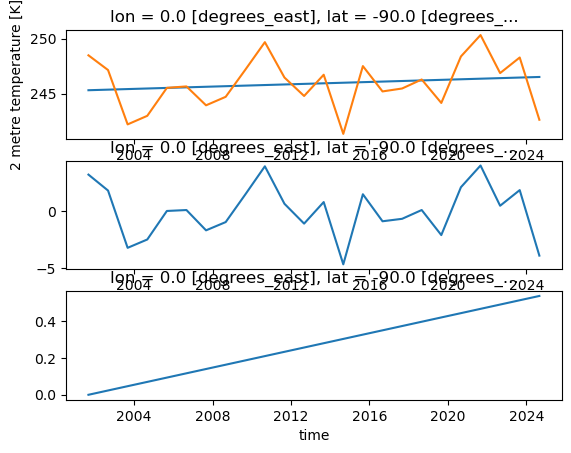

In [48]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1)
era5_spring_trend_g2000_da.isel(lat=0, lon=0).plot(ax=ax1)
era5_spring_g2000_da.isel(lat=0, lon=0).plot(ax=ax1)
era5_spring_g2000_da_detrend.isel(lat=0, lon=0).plot(ax=ax2)
era5_spring_g2000_sn_da.isel(lat=0, lon=0).plot(ax=ax3)

## Plotting

In [190]:
model

'HadGEM3-GC31-LL'

Text(0.5, 0.975, 'ERA5 spring (SON) maximum SAT, 2000 onwards')

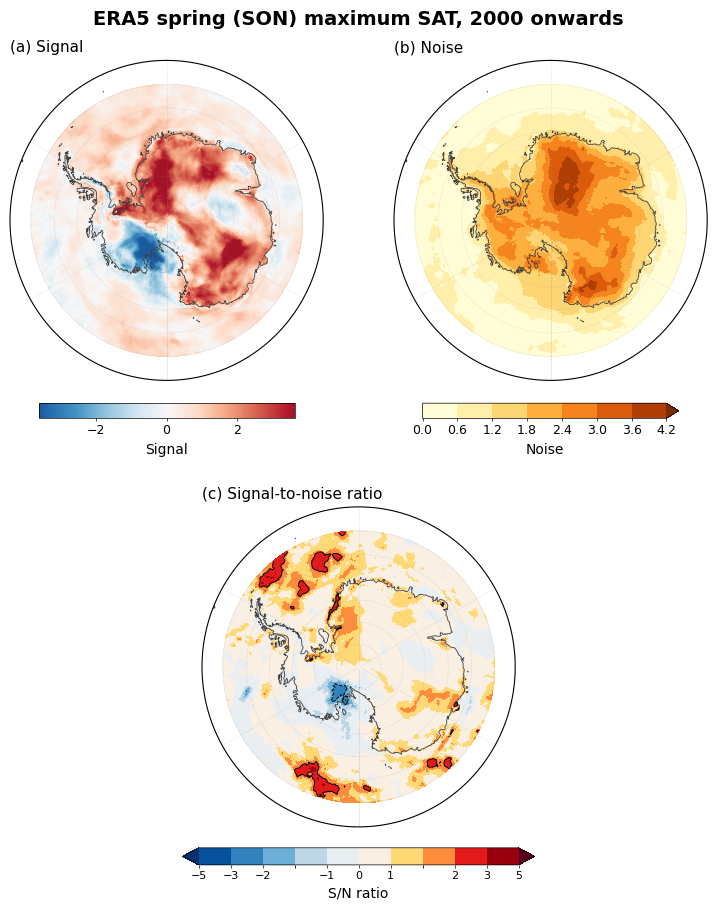

In [49]:
import numpy as np
import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.path as mpath


def truncate_cmap(name, lo=0.0, hi=1.0, n=256):
    base = mpl.colormaps[name]
    return mcolors.LinearSegmentedColormap.from_list(
        f'{name}_{lo}_{hi}', base(np.linspace(lo, hi, n)))


SIG_CMAP = truncate_cmap('RdBu_r', 0.08, 0.92)
NOISE_CMAP = truncate_cmap('YlOrBr', 0.05, 0.95)

# 9 bins: 4 negative (blue), 1 central "below noise" (grey), 4 positive (yellow->red)
SN_LEVELS = [-5, -3, -2, -1.5, -1, 0, 1, 1.5, 2, 3, 5]
SN_TICKS = [-5, -3, -2, -1, 0, 1, 2, 3, 5]
SN_CMAP = mcolors.ListedColormap(
    ['#08519c', '#3182bd', '#6baed6', '#bdd7e7',
     '#e8eef2', '#f9efe2',
     '#fed976', '#fd8d3c', '#e31a1c', '#99000d'])
SN_CMAP.set_under('#08306b')
SN_CMAP.set_over('#54001a')
SN_NORM = mcolors.BoundaryNorm(SN_LEVELS, SN_CMAP.N)

UNIVERSAL_PLOT_KWARGS = dict(transform=ccrs.PlateCarree(), add_labels=False,
                             add_colorbar=False)

# --- figure and axes (explicit positions, figure coordinates) ---
fig = plt.figure(figsize=(8, 9.5))

MAP_W = 0.40
MAP_H = MAP_W * 8 / 9.5   # square in inches

ax_a = fig.add_axes([0.06, 0.585, MAP_W, MAP_H], projection=ccrs.SouthPolarStereo())
ax_b = fig.add_axes([0.54, 0.585, MAP_W, MAP_H], projection=ccrs.SouthPolarStereo())
ax_c = fig.add_axes([0.30, 0.115, MAP_W, MAP_H], projection=ccrs.SouthPolarStereo())

cax_a = fig.add_axes([0.10, 0.545, 0.32, 0.016])
cax_b = fig.add_axes([0.58, 0.545, 0.32, 0.016])
cax_c = fig.add_axes([0.28, 0.075, 0.44, 0.018])

# --- data ---
p_a = era5_spring_g2000_signal_da.isel(time=-1).plot(
    ax=ax_a, robust=True, cmap=SIG_CMAP, **UNIVERSAL_PLOT_KWARGS)
p_b = era5_spring_g2000_noise_da.plot(
    ax=ax_b, robust=True, levels=7, cmap=NOISE_CMAP, extend='max',
    **UNIVERSAL_PLOT_KWARGS)
p_c = era5_spring_g2000_sn_da.isel(time=-1).plot(
    ax=ax_c, cmap=SN_CMAP, norm=SN_NORM, **UNIVERSAL_PLOT_KWARGS)

era5_spring_g2000_sn_da.isel(time=-1).plot.contour(
    ax=ax_c, levels=[-2, 2], colors='k', linewidths=0.7, add_labels=False,
    transform=ccrs.PlateCarree())

# --- colorbars ---
cb_a = fig.colorbar(p_a, cax=cax_a, orientation='horizontal', label='Signal')
cb_b = fig.colorbar(p_b, cax=cax_b, orientation='horizontal', label='Noise')
cb_c = fig.colorbar(p_c, cax=cax_c, orientation='horizontal', label='S/N ratio',
                    extend='both', ticks=SN_TICKS, spacing='uniform')

for cb in (cb_a, cb_b, cb_c):
    cb.outline.set_linewidth(0.5)
    cb.ax.tick_params(labelsize=9, length=2, width=0.5, pad=2)
    cb.ax.xaxis.label.set_size(10)

cb_c.ax.tick_params(labelsize=8)
cb_c.dividers.set_color('white')
cb_c.dividers.set_linewidth(0.8)

# --- map furniture ---
theta = np.linspace(0, 2 * np.pi, 200)
circle = mpath.Path(np.column_stack([np.sin(theta), np.cos(theta)]) * 0.5 + 0.5)

for ax in (ax_a, ax_b, ax_c):
    ax.set_extent([-180, 180, -90, -55], crs=ccrs.PlateCarree())
    ax.set_boundary(circle, transform=ax.transAxes)
    ax.coastlines(linewidth=0.6, color='0.25')
    ax.gridlines(linewidth=0.4, color='0.6', alpha=0.5, linestyle=':')

ax_a.set_title('(a) Signal', loc='left', fontsize=11)
ax_b.set_title('(b) Noise', loc='left', fontsize=11)
ax_c.set_title('(c) Signal-to-noise ratio', loc='left', fontsize=11)

fig.suptitle('ERA5 spring (SON) maximum SAT, 2000 onwards', fontsize=14, fontweight='bold', y=0.975)

In [51]:
# era5_spring_slope_da = grid_slope(era5_seasonal_da).compute()

In [52]:
def max_locations(ds, number:int=10, ascending=True) -> list:
    ds = ds.stack(latlon=['lat', 'lon'])
    ds = ds.sortby(ds, ascending=ascending)
    latlon_largest = ds.isel(latlon=slice(0, number)).latlon.values
    latlon_largest_formatted = [{'lat': latlon[0], 'lon': latlon[1]} for latlon in latlon_largest]
    return  latlon_largest_formatted

In [53]:
latlon_largest_era5_seasonal = max_locations(era5_spring_slope_g2000_da, ascending=False)
latlon_largest_era5_seasonal

[{'lat': -74.0, 'lon': 112.25},
 {'lat': -73.75, 'lon': 112.0},
 {'lat': -74.0, 'lon': 112.0},
 {'lat': -74.0, 'lon': 112.5},
 {'lat': -73.75, 'lon': 112.25},
 {'lat': -73.75, 'lon': 111.75},
 {'lat': -74.25, 'lon': 112.75},
 {'lat': -74.25, 'lon': 112.5},
 {'lat': -74.25, 'lon': 112.25},
 {'lat': -74.0, 'lon': 111.75}]

In [59]:
latlon_largest_era5_seasonal_sn = max_locations(era5_spring_g2000_sn_da.isel(time=-1), ascending=False)
latlon_largest_era5_seasonal_sn

[{'lat': -65.0, 'lon': 203.75},
 {'lat': -65.0, 'lon': 203.5},
 {'lat': -65.0, 'lon': 204.0},
 {'lat': -65.25, 'lon': 203.75},
 {'lat': -65.0, 'lon': 203.25},
 {'lat': -65.25, 'lon': 203.5},
 {'lat': -65.0, 'lon': 204.25},
 {'lat': -65.25, 'lon': 204.0},
 {'lat': -65.25, 'lon': 203.25},
 {'lat': -65.0, 'lon': 203.0}]

In [106]:
import matplotlib.pyplot as plt


def make_axes(fig, npanels, layout="col", height_ratios=(5, 1)):
    axes, tab_axes = [], []
    if layout == "col":
        gs = fig.add_gridspec(2, npanels, height_ratios=height_ratios)
        slots = [(gs[0, i], gs[1, i]) for i in range(npanels)]
    elif layout == "row":
        gs = fig.add_gridspec(2 * npanels, 1,
                              height_ratios=list(height_ratios) * npanels)
        slots = [(gs[2 * i, 0], gs[2 * i + 1, 0]) for i in range(npanels)]
    else:
        raise ValueError("layout must be 'col' or 'row'")

    for plot_slot, tab_slot in slots:
        axes.append(fig.add_subplot(plot_slot, sharex=axes[0] if axes else None))
        tab_axes.append(fig.add_subplot(tab_slot))
    return axes, tab_axes


def plot_signal_sn(points, left_key, right_key, table_keys,
                   layout="col", figsize=None, height_ratios=(5, 1),
                   left_color="tab:blue", right_color="tab:red",
                   left_label="Temperature (K)"):
    n = len(points)
    if figsize is None:
        figsize = (6 * n, 5) if layout == "col" else (7, 3.5 * n)

    fig = plt.figure(figsize=figsize, constrained_layout=True)
    axes, tab_axes = make_axes(fig, n, layout, height_ratios)

    for ax, ax_tab, p in zip(axes, tab_axes, points):
        draw_panel(ax, p["label"], p["pt"], p["data"], left_key, right_key,
                   left_color=left_color, right_color=right_color,
                   left_label=left_label)
        draw_table(ax_tab, p["data"], table_keys)

    return fig, axes

In [166]:
def draw_panel(ax, label, pt, data, left_key, right_key,
               left_color="tab:blue", right_color="tab:red",
               left_label="Temperature (K)"):
    left, right = data[left_key], data[right_key]

    l1, = ax.plot(left.time, left, color=left_color, lw=1.2,
                  label=f"{left_key}")
    ax.set_ylabel(left_label, color=left_color)
    ax.tick_params(axis="y", labelcolor=left_color, length=3)
    ax.tick_params(axis="x", length=3)
    ax.set_title(f"{label}: {pt['lat']}°, {pt['lon']}°", fontsize=11, pad=8)
    ax.grid(alpha=0.25, lw=0.6)
    ax.set_axisbelow(True)

    ax2 = ax.twinx()
    l2, = ax2.plot(right.time, right, color=right_color, lw=1.8,
                   label=f"{right_key} ({endpoint(right):.2f})")
    ax2.set_ylabel(right_key, color=right_color)
    ax2.tick_params(axis="y", labelcolor=right_color, length=3)
    ax2.axhline(0, color="0.5", lw=0.8, ls=":")

    ax.spines["top"].set_visible(False)
    ax2.spines["top"].set_visible(False)
    ax.legend(handles=[l1, l2], loc="upper left", frameon=False, fontsize=12)
    return ax2

In [167]:
def draw_table(ax, data, table_keys):
    ax.axis("off")
    tab = ax.table(cellText=[[f"{endpoint(data[k]):.2f}" for k in table_keys]],
                   colLabels=list(table_keys),
                   cellLoc="center", loc="center")
    tab.auto_set_font_size(False)
    tab.set_fontsize(9)
    tab.scale(1, 1.3)
    for (r, c), cell in tab.get_celld().items():
        cell.set_edgecolor("0.8")
        if r == 0:
            cell.set_text_props(weight="bold")
    return tab

In [168]:
def extract_point(label, pt, arrays):
    sel = dict(lat=pt["lat"], lon=pt["lon"], method="nearest")
    return {"label": label,
            "pt": pt,
            "data": {name: da.sel(**sel) for name, da in arrays.items()}}

def endpoint(da):
    return da.isel(time=-1).values if "time" in da.dims else da.values

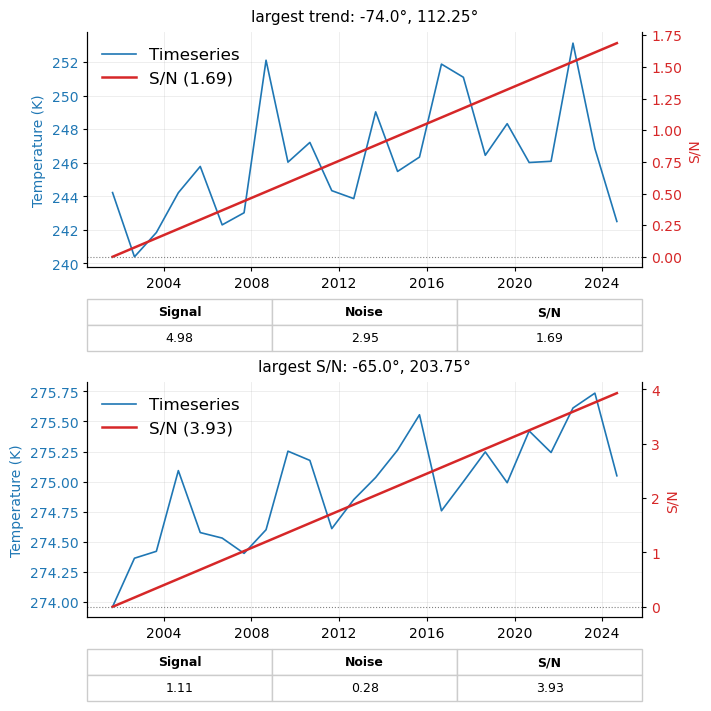

In [169]:
arrays = {
    "Timeseries": era5_spring_g2000_da,
    "Signal": era5_spring_g2000_signal_da,
    "Noise": era5_spring_g2000_noise_da,
    "S/N": era5_spring_g2000_sn_da,
}

fig, axes = plot_signal_sn(
    points=[extract_point("largest trend", latlon_largest_era5_seasonal[0], arrays),
            extract_point("largest S/N", latlon_largest_era5_seasonal_sn[0], arrays)],
    left_key="Timeseries",
    right_key="S/N",
    table_keys=["Signal", "Noise", "S/N"],
    layout="row",
)

## Hist Nat

This section compares the ERA5 against HadGEM3-GC31-LL. The trends here are from 1979 to 2014. Trends are again for spring daily maximum temperature.

- Signal (S): This is calculated using LOWESS
- Noise (N): Standard deviation of residuals

Currently this is just for a single ensemble member.

In [133]:
hist_seasonal_ds = hist_ds.resample(time='QS-DEC').max()
hist_seasonal_ds

<xarray.DataArray 'tasmax' (time: 661, lat: 24, lon: 192)> Size: 12MB
dask.array<transpose, shape=(661, 24, 192), dtype=float32, chunksize=(81, 24, 192), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 192B -89.38 -88.12 -86.88 ... -63.12 -61.88 -60.62
  * lon      (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
    height   float64 8B 1.5
  * time     (time) object 5kB 1849-12-01 00:00:00 ... 2014-12-01 00:00:00
Attributes:
    standard_name:  air_temperature
    long_name:      Daily Maximum Near-Surface Air Temperature
    comment:        maximum near-surface (usually, 2 meter) air temperature (...
    units:          K
    original_name:  mo: (stash: m01s03i236, lbproc: 8192)
    cell_methods:   area: mean time: maximum
    cell_measures:  area: areacella
    history:        2023-05-16T18:37:57Z altered by CMOR: Treated scalar dime...

In [144]:
hist_seasonal_match_ds = hist_seasonal_ds.sel(time=hist_seasonal_ds['time.month']==9)
era5_seasonal_match_da = era5_seasonal_da.sel(time=era5_seasonal_da['time.month']==9)

hist_seasonal_match_ds = hist_seasonal_match_ds.where(hist_seasonal_match_ds.time.dt.year.isin(era5_seasonal_match_da.time.dt.year.values), drop=True)
era5_seasonal_match_da = era5_seasonal_match_da.where(era5_seasonal_match_da.time.dt.year.isin(hist_seasonal_match_ds.time.dt.year.values), drop=True)

# hist_seasonal_match_ds = hist_seasonal_ds.where(hist_seasonal_ds.time.dt.year.isin(era5_seasonal_da.time.dt.year.values), drop=True)



In [145]:
np.unique(hist_seasonal_match_ds.time.dt.year.values, return_counts=True)

(array([1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989,
        1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000,
        2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
        2012, 2013, 2014]),
 array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]))

In [147]:
np.unique(era5_seasonal_match_da.time.dt.year.values, return_counts=True)

(array([1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989,
        1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000,
        2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
        2012, 2013, 2014]),
 array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]))

In [148]:
len(hist_seasonal_match_ds.time.values), len(era5_seasonal_match_da.time.values)

(36, 36)

In [149]:
hist_seasonal_match_ds['time'] = era5_seasonal_match_da.time.values

In [150]:
from statsmodels.nonparametric.smoothers_lowess import lowess

In [151]:
def lowess_func(arr):
    return lowess(arr, np.arange(arr.shape[0]), return_sorted=False)

In [152]:
era5_lowss = xr.apply_ufunc(
    lowess_func,
    era5_seasonal_match_da,
    input_core_dims=[['time']],
    output_core_dims=[['time']],
    dask='parallelized',
    vectorize=True,
    dask_gufunc_kwargs={'allow_rechunk':True},
    output_dtypes=[float]
    
).compute()
wait(era5_lowss);

In [153]:
hist_lowss = xr.apply_ufunc(
    lowess_func,
    hist_seasonal_match_ds,
    input_core_dims=[['time']],
    output_core_dims=[['time']],
    dask='parallelized',
    vectorize=True,
    dask_gufunc_kwargs={'allow_rechunk':True}
    # ouput_dtypes=[float]
    
).compute()
wait(hist_seasonal_match_ds);

In [154]:
hist_lowss_anom = hist_lowss - hist_lowss.isel(time=0)
era5_lowss_anom = era5_lowss - era5_lowss.isel(time=0)

In [155]:
era5_lowss_anom

<xarray.DataArray 'tasmax' (lat: 121, lon: 1440, time: 36)> Size: 50MB
array([[[ 0.        , -0.08705785, -0.15675333, ...,  1.05674336,
          0.9993553 ,  0.94308413],
        [ 0.        , -0.08705785, -0.15675333, ...,  1.05674336,
          0.9993553 ,  0.94308413],
        [ 0.        , -0.08705785, -0.15675333, ...,  1.05674336,
          0.9993553 ,  0.94308413],
        ...,
        [ 0.        , -0.08705785, -0.15675333, ...,  1.05674336,
          0.9993553 ,  0.94308413],
        [ 0.        , -0.08705785, -0.15675333, ...,  1.05674336,
          0.9993553 ,  0.94308413],
        [ 0.        , -0.08705785, -0.15675333, ...,  1.05674336,
          0.9993553 ,  0.94308413]],

       [[ 0.        , -0.08452606, -0.15240859, ...,  1.33860852,
          1.32131757,  1.30554542],
        [ 0.        , -0.084653  , -0.15265729, ...,  1.33820808,
          1.32106916,  1.30545304],
        [ 0.        , -0.08479609, -0.15294413, ...,  1.33737665,
          1.32027922,  1.30470801],
...
        [ 0.        , -0.0252146 , -0.05055765, ..., -0.19052307,
         -0.18113454, -0.17104709],
        [ 0.        , -0.02519891, -0.05072766, ..., -0.1997138 ,
         -0.18901967, -0.17760979],
        [ 0.        , -0.02647396, -0.05348744, ..., -0.21496134,
         -0.20295877, -0.19026808]],

       [[ 0.        , -0.02306288, -0.04659688, ..., -0.22692713,
         -0.21916807, -0.21079805],
        [ 0.        , -0.02470074, -0.04994412, ..., -0.23578379,
         -0.22783117, -0.21937314],
        [ 0.        , -0.02424803, -0.04909242, ..., -0.2374191 ,
         -0.22929899, -0.22069605],
        ...,
        [ 0.        , -0.02256114, -0.04565095, ..., -0.258767  ,
         -0.254153  , -0.24894965],
        [ 0.        , -0.02091864, -0.04238052, ..., -0.23691121,
         -0.23132764, -0.22509466],
        [ 0.        , -0.02259796, -0.0456763 , ..., -0.23439905,
         -0.22747001, -0.21990758]]], shape=(121, 1440, 36))
Coordinates:
  * lon      (lon) float32 6kB 0.0 0.25 0.5 0.75 1.0 ... 359.0 359.2 359.5 359.8
  * lat      (lat) float32 484B -90.0 -89.75 -89.5 -89.25 ... -60.5 -60.25 -60.0
  * time     (time) datetime64[ns] 288B 1979-09-01 1980-09-01 ... 2014-09-01

In [156]:
hist_noise = (hist_seasonal_match_ds - hist_lowss).std(dim='time').compute()
era5_noise = (era5_seasonal_match_da - era5_lowss_anom).std(dim='time').compute()

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 47.94 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [157]:
hist_sn = hist_lowss_anom/hist_noise
era5_sn = era5_lowss_anom/era5_noise

Text(0.5, 0.955, 'ERA5 spring (SON), 2000 onwards')

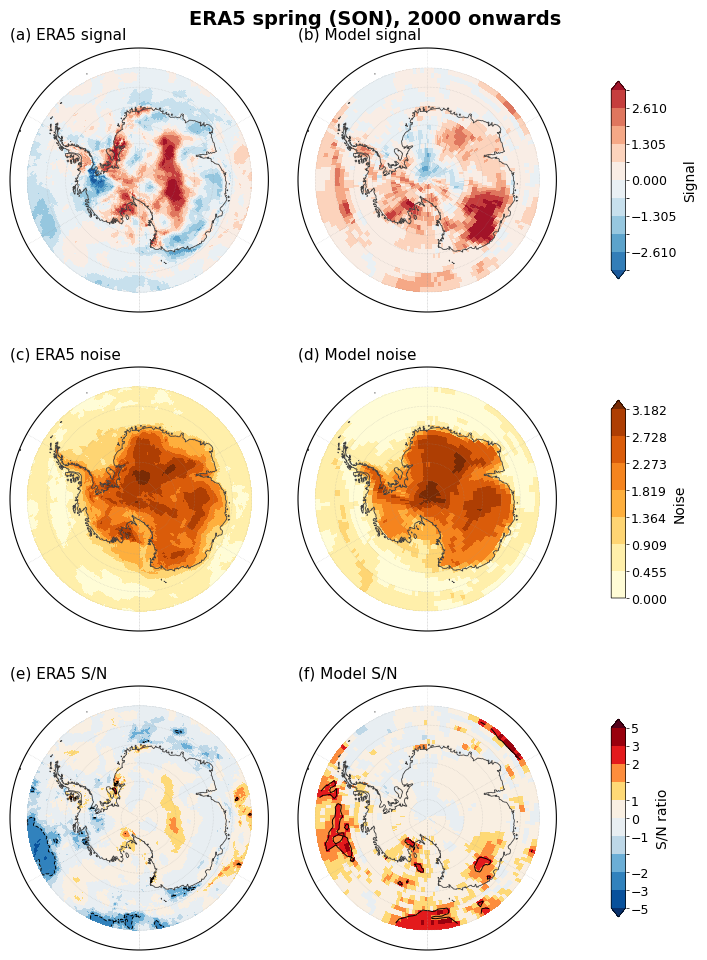

In [158]:
import numpy as np
import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.path as mpath


def truncate_cmap(name, lo=0.0, hi=1.0, n=256):
    base = mpl.colormaps[name]
    return mcolors.LinearSegmentedColormap.from_list(
        f'{name}_{lo}_{hi}', base(np.linspace(lo, hi, n)))


SIG_CMAP = truncate_cmap('RdBu_r', 0.08, 0.92)
NOISE_CMAP = truncate_cmap('YlOrBr', 0.05, 0.95)

SN_LEVELS = [-5, -3, -2, -1.5, -1, 0, 1, 1.5, 2, 3, 5]
SN_TICKS = [-5, -3, -2, -1, 0, 1, 2, 3, 5]
SN_CMAP = mcolors.ListedColormap(
    ['#08519c', '#3182bd', '#6baed6', '#bdd7e7',
     '#e8eef2', '#f9efe2',
     '#fed976', '#fd8d3c', '#e31a1c', '#99000d'])
SN_CMAP.set_under('#08306b')
SN_CMAP.set_over('#54001a')
SN_NORM = mcolors.BoundaryNorm(SN_LEVELS, SN_CMAP.N)

UNIVERSAL_PLOT_KWARGS = dict(transform=ccrs.PlateCarree(), add_labels=False,
                             add_colorbar=False)

# --- fields ---
sig = {'ERA5': era5_lowss_anom.isel(time=-1), 'Model': hist_lowss_anom.isel(time=-1)}
noise = {'ERA5': era5_noise, 'Model': hist_noise}
sn = {'ERA5': era5_sn.isel(time=-1), 'Model': hist_sn.isel(time=-1)}

# shared limits so the two columns are on the same scale
sig_vmax = float(np.nanpercentile(
    np.abs(np.concatenate([d.values.ravel() for d in sig.values()])), 98))
noise_vmax = float(np.nanpercentile(
    np.concatenate([d.values.ravel() for d in noise.values()]), 98))

SIG_LEVELS = np.linspace(-sig_vmax, sig_vmax, 11)
NOISE_LEVELS = np.linspace(0, noise_vmax, 8)

# --- figure and axes (explicit positions, figure coordinates) ---
fig = plt.figure(figsize=(8, 11))

MAP_W = 0.33
MAP_H = MAP_W * 8 / 11   # square in inches

COL_X = {'ERA5': 0.04, 'Model': 0.40}
ROW_Y = {'sig': 0.680, 'noise': 0.390, 'sn': 0.100}
CBAR_X, CBAR_W = 0.795, 0.018

axes = {(row, col): fig.add_axes([COL_X[col], ROW_Y[row], MAP_W, MAP_H],
                                 projection=ccrs.SouthPolarStereo())
        for row in ROW_Y for col in COL_X}

caxes = {row: fig.add_axes([CBAR_X, ROW_Y[row] + 0.03, CBAR_W, MAP_H - 0.06])
         for row in ROW_Y}

# --- data ---
for col in COL_X:
    p_sig = sig[col].plot(ax=axes[('sig', col)], levels=SIG_LEVELS, cmap=SIG_CMAP,
                          extend='both', **UNIVERSAL_PLOT_KWARGS)
    p_noise = noise[col].plot(ax=axes[('noise', col)], levels=NOISE_LEVELS,
                              cmap=NOISE_CMAP, extend='max', **UNIVERSAL_PLOT_KWARGS)
    p_sn = sn[col].plot(ax=axes[('sn', col)], cmap=SN_CMAP, norm=SN_NORM,
                        **UNIVERSAL_PLOT_KWARGS)
    sn[col].plot.contour(ax=axes[('sn', col)], levels=[-2, 2], colors='k',
                         linewidths=0.7, add_labels=False,
                         transform=ccrs.PlateCarree())

# --- colorbars (one per row, shared across columns) ---
cb_sig = fig.colorbar(p_sig, cax=caxes['sig'], label='Signal')
cb_noise = fig.colorbar(p_noise, cax=caxes['noise'], label='Noise')
cb_sn = fig.colorbar(p_sn, cax=caxes['sn'], label='S/N ratio',
                     extend='both', ticks=SN_TICKS, spacing='uniform')

for cb in (cb_sig, cb_noise, cb_sn):
    cb.outline.set_linewidth(0.5)
    cb.ax.tick_params(labelsize=9, length=2, width=0.5, pad=2)
    cb.ax.yaxis.label.set_size(10)

cb_sn.dividers.set_color('white')
cb_sn.dividers.set_linewidth(0.8)

# --- map furniture ---
theta = np.linspace(0, 2 * np.pi, 200)
circle = mpath.Path(np.column_stack([np.sin(theta), np.cos(theta)]) * 0.5 + 0.5)

for ax in axes.values():
    ax.set_extent([-180, 180, -90, -55], crs=ccrs.PlateCarree())
    ax.set_boundary(circle, transform=ax.transAxes)
    ax.coastlines(linewidth=0.6, color='0.25')
    ax.gridlines(linewidth=0.4, color='0.6', alpha=0.5, linestyle=':')

PANEL_LABELS = {('sig', 'ERA5'): '(a) ERA5 signal',
                ('sig', 'Model'): '(b) Model signal',
                ('noise', 'ERA5'): '(c) ERA5 noise',
                ('noise', 'Model'): '(d) Model noise',
                ('sn', 'ERA5'): '(e) ERA5 S/N',
                ('sn', 'Model'): '(f) Model S/N'}

for key, label in PANEL_LABELS.items():
    axes[key].set_title(label, loc='left', fontsize=11)

fig.suptitle('ERA5 spring (SON), 2000 onwards', fontsize=14, fontweight='bold', y=0.955)

Text(0.5, 1.0, 'ERA5')

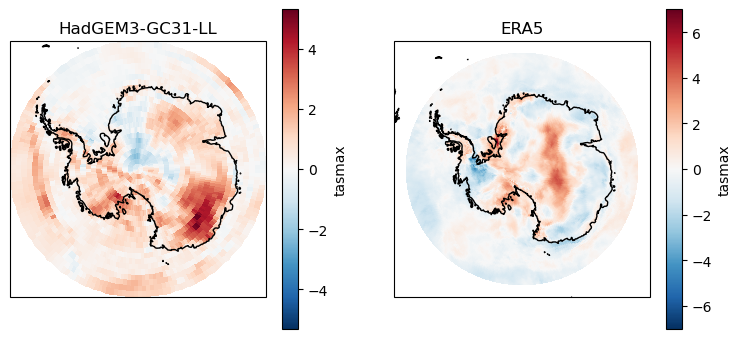

In [159]:
# --- figure and axes (explicit positions, figure coordinates) ---
fig = plt.figure(figsize=(8, 9.5))

MAP_W = 0.40
MAP_H = MAP_W * 8 / 9.5   # square in inches

ax_a = fig.add_axes([0.06, 0.585, MAP_W, MAP_H], projection=ccrs.SouthPolarStereo())
ax_b = fig.add_axes([0.54, 0.585, MAP_W, MAP_H], projection=ccrs.SouthPolarStereo())

hist_lowss_anom.isel(time=-1).plot(ax=ax_a, transform=ccrs.PlateCarree())
era5_lowss_anom.isel(time=-1).plot(ax=ax_b, transform=ccrs.PlateCarree())

axes = [ax_a, ax_b]

for ax in axes:
    ax.coastlines()


ax_a.set_title(model)
ax_b.set_title('ERA5')

# ax_c = fig.add_axes([0.30, 0.115, MAP_W, MAP_H], projection=ccrs.SouthPolarStereo())

# cax_a = fig.add_axes([0.10, 0.545, 0.32, 0.016])
# cax_b = fig.add_axes([0.58, 0.545, 0.32, 0.016])
# cax_c = fig.add_axes([0.28, 0.075, 0.44, 0.018])

In [160]:
import nc_time_axis  # noqa: F401

In [183]:
def to_year(da):
    return da.assign_coords(time=da.time.dt.year) if "time" in da.dims else da


def build_points(stations, arrays):
    return [{"label": label,
             "pt": pt,
             "data": {name: to_year(da).sel(lat=pt["lat"], lon=pt["lon"],
                                            method="nearest").compute()
                      for name, da in arrays.items()}}
            for label, pt in stations.items()]

In [188]:
def make_axes(fig, npanels, n_series_rows=2, layout="col",
              height_ratios=(3, 3, 2, 1)):
    nrows = n_series_rows + 2
    series_axes, sn_axes, tab_axes = [], [], []
    if layout == "col":
        gs = fig.add_gridspec(nrows, npanels, height_ratios=height_ratios)
        slots = [[gs[r, i] for r in range(nrows)] for i in range(npanels)]
    elif layout == "row":
        gs = fig.add_gridspec(nrows * npanels, 1,
                              height_ratios=list(height_ratios) * npanels)
        slots = [[gs[nrows * i + r, 0] for r in range(nrows)]
                 for i in range(npanels)]
    else:
        raise ValueError("layout must be 'col' or 'row'")

    for col_slots in slots:
        shared_x = series_axes[0][0] if series_axes else None
        col = []
        for r in range(n_series_rows):
            ax = fig.add_subplot(col_slots[r], sharex=shared_x,
                                 sharey=col[0] if col else None)
            shared_x = shared_x or ax
            col.append(ax)
        series_axes.append(col)
        sn_axes.append(fig.add_subplot(col_slots[-2], sharex=col[0]))
        tab_axes.append(fig.add_subplot(col_slots[-1]))
    return series_axes, sn_axes, tab_axes

def draw_compare_panel(ax_list, ax_sn, label, pt, data, series_rows, sn_keys,
                       series_label="Anomaly (K)", sn_label="S/N ratio",
                       row_labels=None, show_row_labels=True):
    for i, (ax, row) in enumerate(zip(ax_list, series_rows)):
        for key, style in row.items():
            data[key].plot(ax=ax, **style)
        ax.axhline(0, color="0.75", lw=0.6, zorder=0)
        ax.set_ylabel(series_label)
        ax.set_xlabel("")
        ax.set_title("")
        ax.tick_params(labelbottom=False)
        ax.legend(fontsize=8, loc="upper left", framealpha=0.9, ncol=2)
        if row_labels and show_row_labels:
            ax.text(-0.22, 0.5, row_labels[i], transform=ax.transAxes,
                    rotation=90, va="center", ha="center",
                    fontsize=11, fontweight="bold")

    for key, style in sn_keys.items():
        data[key].plot(ax=ax_sn, **style)
    for y in (-2, -1, 1, 2):
        ax_sn.axhline(y, color="0.75", lw=0.6, ls=":", zorder=0)
    ax_sn.axhline(0, color="0.75", lw=0.6, zorder=0)
    ax_sn.set_ylabel(sn_label)
    ax_sn.set_xlabel("Year")
    ax_sn.set_title("")
    ax_sn.legend(fontsize=8, loc="upper left", framealpha=0.9, ncol=2)
    if row_labels and show_row_labels and len(row_labels) > len(series_rows):
        ax_sn.text(-0.22, 0.5, row_labels[-1], transform=ax_sn.transAxes,
                   rotation=90, va="center", ha="center",
                   fontsize=11, fontweight="bold")

    ax_list[0].set_title(f"{label}   {pt['lat']:.1f}°, {pt['lon']:.1f}°",
                         loc="left", fontsize=11, fontweight="bold")


def plot_compare(points, series_rows, sn_keys, table_keys,
                 layout="col", figsize=None, height_ratios=(3, 3, 2, 1),
                 row_labels=None, **kwargs):
    n = len(points)
    if figsize is None:
        figsize = (5.5 * n, 8.5) if layout == "col" else (7, 6 * n)
    fig = plt.figure(figsize=figsize, constrained_layout=True)
    series_axes, sn_axes, tab_axes = make_axes(fig, n, len(series_rows),
                                               layout, height_ratios)
    for i, (ax_list, ax_sn, ax_tab, p) in enumerate(
            zip(series_axes, sn_axes, tab_axes, points)):
        draw_compare_panel(ax_list, ax_sn, p["label"], p["pt"], p["data"],
                           series_rows, sn_keys, row_labels=row_labels,
                           show_row_labels=(i == 0 or layout == "row"), **kwargs)
        draw_table(ax_tab, p["data"], table_keys)
    return fig, series_axes, sn_axes

In [184]:
points = build_points(STATIONS, COMPARE_ARRAYS)

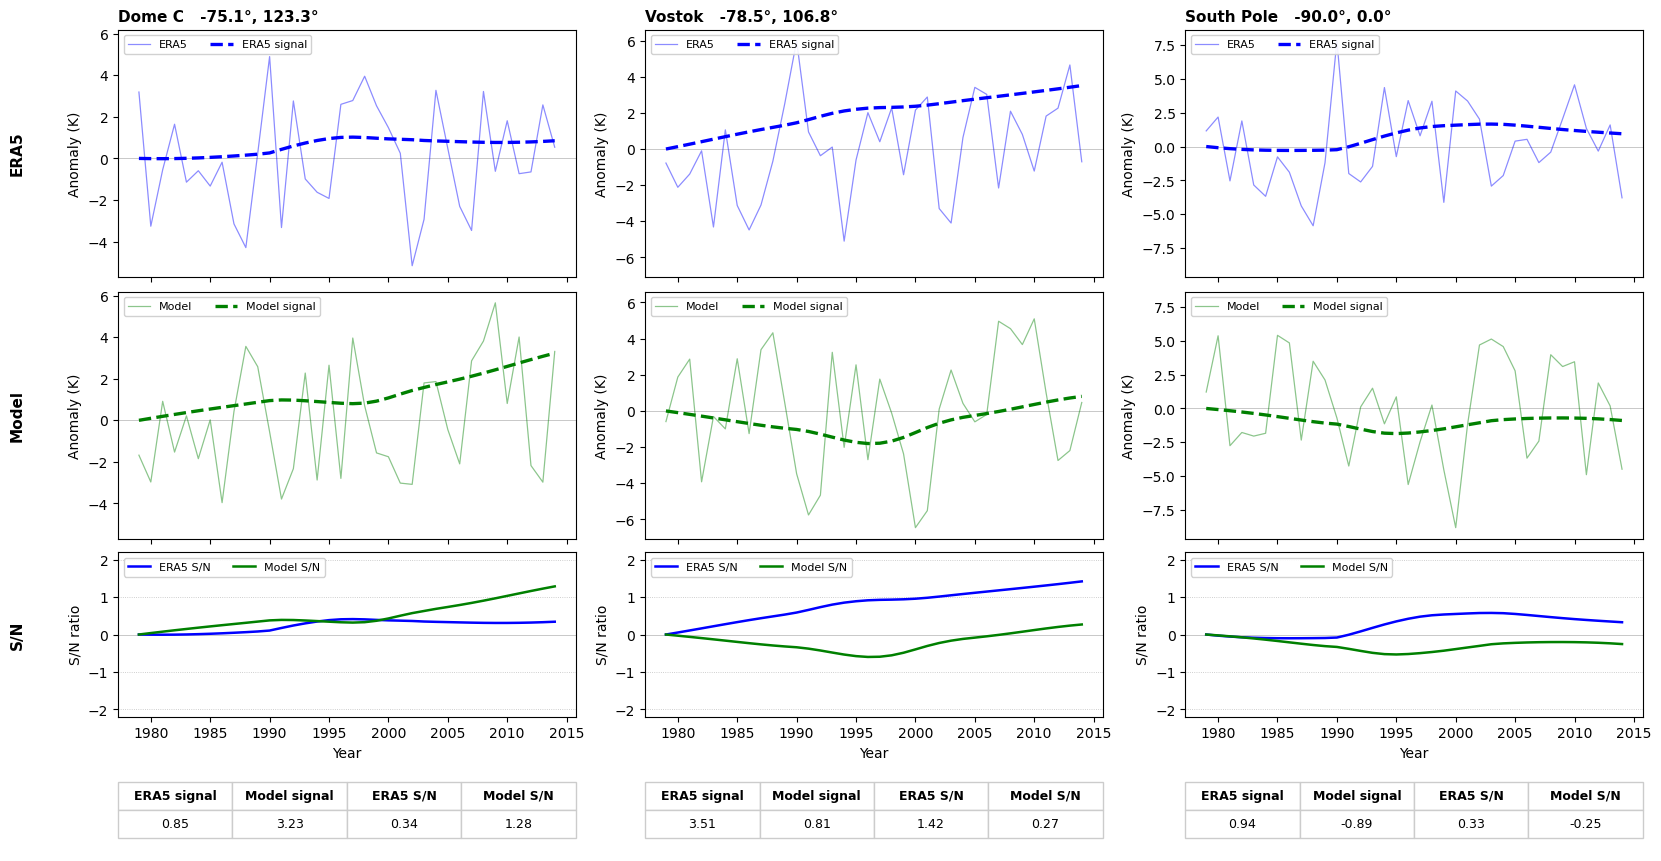

In [189]:
ERA5_C, MODEL_C = "blue", "green"   # Okabe–Ito blue / vermillion

SERIES_ROWS = [
    {"ERA5":         dict(color=ERA5_C, lw=0.9, alpha=0.45, label="ERA5"),
     "ERA5 signal":  dict(color=ERA5_C, lw=2.4, ls="--", label="ERA5 signal")},
    {"Model":        dict(color=MODEL_C, lw=0.9, alpha=0.45, label="Model"),
     "Model signal": dict(color=MODEL_C, lw=2.4, ls="--", label="Model signal")},
]
SN = {
    "ERA5 S/N":  dict(color=ERA5_C, lw=1.8, label="ERA5 S/N"),
    "Model S/N": dict(color=MODEL_C, lw=1.8, label="Model S/N"),
}

fig, series_axes, sn_axes = plot_compare(
    points=points,
    series_rows=SERIES_ROWS, sn_keys=SN,
    table_keys=["ERA5 signal", "Model signal", "ERA5 S/N", "Model S/N"],
    row_labels=["ERA5", "Model", "S/N"],
)

### Trends

In [ ]:
hist_summer_ds = hist_seasonal_ds#.sel(time=hist_seasonal_ds['time.month']==6)

In [ ]:
hist_summer_2000_ds = hist_summer_ds.sel(time=hist_summer_ds['time.year']>2000)

In [ ]:
hist_summer_2000_trends_ds = grid_slope(hist_summer_2000_ds).compute()

In [ ]:
hist_summer_2000_sig_ds = grid_mk(hist_summer_2000_ds).compute()

In [ ]:
sig

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

trend = (hist_summer_2000_trends_ds.squeeze(drop=True) * 10).compute()
sig = hist_summer_2000_sig_ds.squeeze(drop=True).compute().sig
m = sig.values.astype(bool)

fig = plt.figure(figsize=(7.5, 7))
ax = fig.add_subplot(111, projection=ccrs.SouthPolarStereo())
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='0.3')
ax.gridlines(linestyle=':', alpha=0.5, color='grey')

vmax = float(abs(trend).quantile(0.98))
im = trend.plot(
    ax=ax, transform=ccrs.PlateCarree(),
    cmap='RdBu_r', vmin=-vmax, vmax=vmax,
    add_colorbar=False,
)

lon2d, lat2d = np.meshgrid(trend.lon.values, trend.lat.values)
ax.scatter(lon2d[m], lat2d[m], s=0.6, c='k', alpha=0.5,
           transform=ccrs.PlateCarree(), rasterized=True)

cb = fig.colorbar(im, ax=ax, orientation='vertical', shrink=0.78, pad=0.06)
cb.ax.tick_params(labelsize=8, length=2)
cb.set_label('TXx trend (K decade$^{-1}$)', fontsize=10)
ax.set_title('DJF TXx trend, 2001–2014 (stipple: p < 0.05)', fontsize=11)

# PR

In [ ]:
import numpy as np


def sorted_percentile(sorted_vals, percentile, n_valid=None):
    """Extract a percentile from a pre-sorted 1D array. O(1).

    Linear interpolation between order statistics, matching np.percentile's
    default (method='linear').

    sorted_vals: sorted ascending, NaNs at the end.
    percentile: in [0, 100].
    n_valid: number of non-NaN values. If None, uses the whole array.
    """
    if np.all(np.isnan(sorted_vals)): return np.nan
        
    if n_valid is None:
        n_valid = len(sorted_vals)
    if n_valid == 0:
        return np.nan

    # Fractional index into the valid block: 0 -> index 0, 100 -> n_valid-1.
    pos = (n_valid - 1) * percentile / 100.0
    below = int(np.floor(pos))
    above = min(below + 1, n_valid - 1)  # clip so 100 doesn't run past the end

    return sorted_vals[below] + (pos - below) * (
        sorted_vals[above] - sorted_vals[below]
    )

In [ ]:
q = 99

In [ ]:
nat_sorted = xr.apply_ufunc(
    np.sort, hist_nat_ds,
    input_core_dims=[['time']],
    output_core_dims=[['time']],
    dask='parallelized',
    output_dtypes=[np.float32],
)

In [ ]:
nat_q = xr.apply_ufunc(
    sorted_percentile, nat_sorted, q,
    input_core_dims=[['time'], []],
    dask='parallelized',
    vectorize=True,
    output_dtypes=[np.float32],
).persist()

In [ ]:
window = 30# * 365

In [ ]:
from dask.distributed import wait

In [ ]:
exceed = (hist_ds > nat_q).persist()
counts_annual = exceed.resample(time='YE').sum().persist()
counts = counts_annual.rolling(time=window).sum().persist()
wait(counts);


p_hist = counts / (window *365)
p_nat = (100 - q) / 100
pr = (p_hist / p_nat)

In [88]:
pr = pr.where(landsea_mask_ds)

In [89]:
# p_hist = counts / window
# p_nat = (100 - q) / 100
# pr = (p_hist / p_nat)

In [90]:
pr = pr.compute()

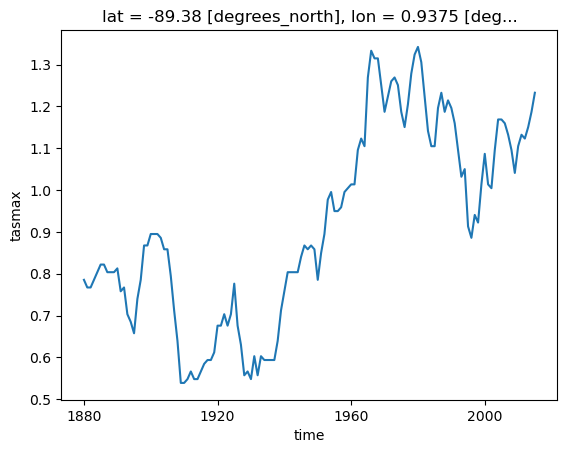

In [91]:
pr.isel(lat=0, lon=0).plot()

In [92]:
qs = pr.quantile([0.0, 0.01, 0.25, 0.5, 0.75, 0.99, 1.0], dim=['lat', 'lon'])

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


Text(0.5, 1.0, 'Spatial spread of PR across Antarctic gridpoints, 99th percentile TXx')

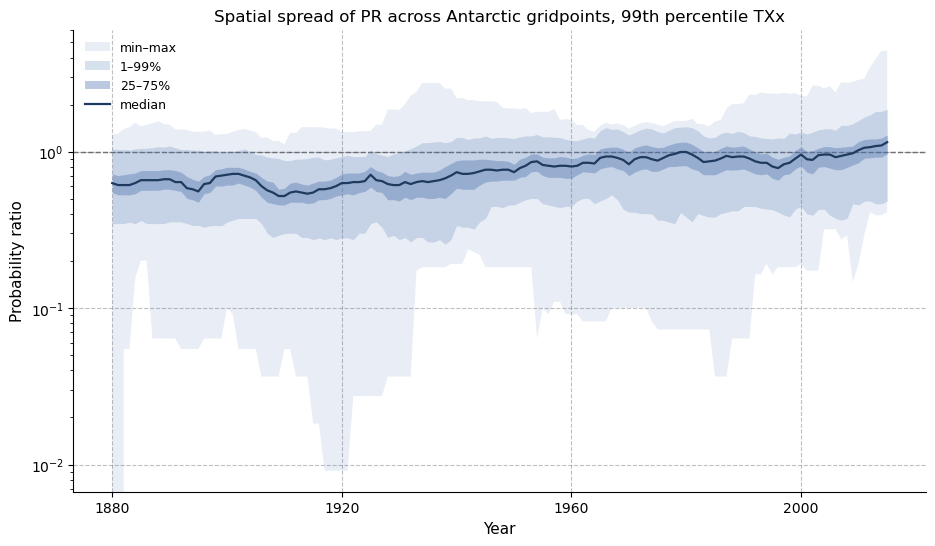

In [93]:
import matplotlib.pyplot as plt
import numpy as np

qs = pr.quantile([0.0, 0.01, 0.25, 0.5, 0.75, 0.99, 1.0], dim=['lat', 'lon'])

fig, ax = plt.subplots(figsize=(11, 6))
ax.axhline(1.0, color='0.4', lw=1.0, ls='--', zorder=1)

ax.fill_between(pr.time.values, qs.sel(quantile=0.0), qs.sel(quantile=1.0),
                color='#4C72B0', alpha=0.12, lw=0, label='min–max', zorder=2)
ax.fill_between(pr.time.values, qs.sel(quantile=0.01), qs.sel(quantile=0.99),
                color='#4C72B0', alpha=0.22, lw=0, label='1–99%', zorder=3)
ax.fill_between(pr.time.values, qs.sel(quantile=0.25), qs.sel(quantile=0.75),
                color='#4C72B0', alpha=0.38, lw=0, label='25–75%', zorder=4)
ax.plot(pr.time, qs.sel(quantile=0.5), lw=1.6, color='#1F3A5F',
        label='median', zorder=5)

ax.set_yscale('log')
ax.set_ylabel('Probability ratio', fontsize=11)
ax.set_xlabel('Year', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5, color='grey')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, fontsize=9, loc='upper left')
ax.set_title(f'Spatial spread of PR across Antarctic gridpoints, {q}th percentile TXx',
             fontsize=12)

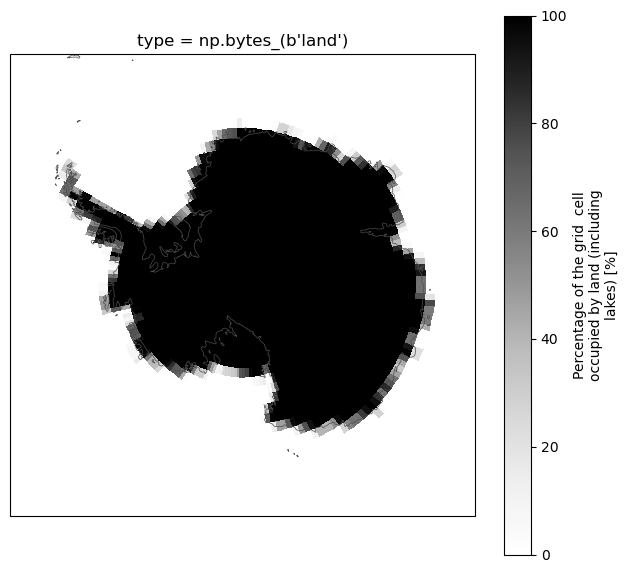

In [106]:
fig = plt.figure(figsize=(7.5, 7))
ax = fig.add_subplot(111, projection=ccrs.SouthPolarStereo())
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())

landsea_mask_ds.sel(lat=slice(-90, -60)).plot(
    ax=ax, transform=ccrs.PlateCarree(),
    cmap='Greys'
)
ax.coastlines(linewidth=0.5, color='0.3')

In [101]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, from_levels_and_colors

ratios = np.array([1.2, 1.4, 1.6, 1.8, 2, 2.5, 3, 4, 5])
levels = np.concatenate([1 / ratios[::-1], [1.0], ratios])

n_neg = int((levels < 1).sum())
n_pos = int((levels > 1).sum())

warm_cmap = plt.get_cmap('inferno_r')          # pale yellow -> orange -> red -> purple
cool_cmap = LinearSegmentedColormap.from_list('pr_cool', [
    '#eafaff', '#a9e0f2', '#5cbcdb', '#2b8cbe', '#225ea8', '#253494', '#101a4d',
])

warm = warm_cmap(np.linspace(0.00, 0.80, n_pos))
cool = cool_cmap(np.linspace(0.03, 0.86, n_neg))[::-1]

colors = np.vstack([cool_cmap(0.97), cool, warm, warm_cmap(0.90)])
cmap, norm = from_levels_and_colors(levels, colors, extend='both')

Text(0.5, 1.0, 'PR, 99th percentile TXx — final 30-yr window')

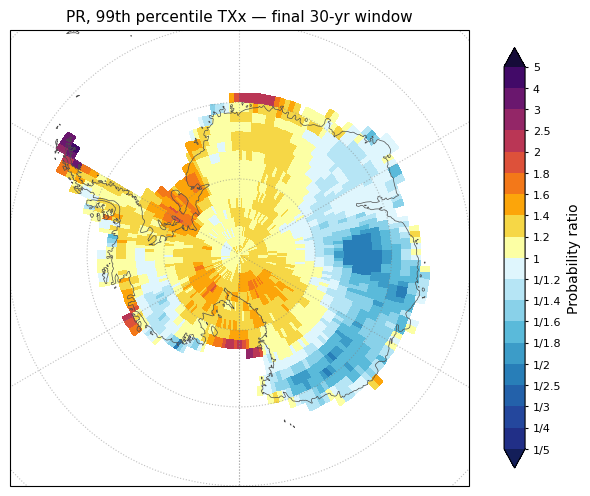

In [102]:
def ratio_label(v):
    if np.isclose(v, 1.0):
        return '1'
    return f'{v:g}' if v > 1 else f'1/{1 / v:g}'

pr_final = pr.isel(time=-1)

fig = plt.figure(figsize=(7.5, 7))
ax = fig.add_subplot(111, projection=ccrs.SouthPolarStereo())
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='0.3')
ax.gridlines(linestyle=':', alpha=0.5, color='grey')

im = pr_final.plot(
    ax=ax, transform=ccrs.PlateCarree(),
    cmap=cmap, norm=norm,
    add_colorbar=False,
)

cb = fig.colorbar(im, ax=ax, orientation='vertical', shrink=0.78, pad=0.06)
cb.set_ticks(levels, labels=[ratio_label(v) for v in levels])
cb.ax.tick_params(labelsize=8, length=2)
cb.set_label('Probability ratio', fontsize=10)

ax.set_title(f'PR, {q}th percentile TXx — final {window}-yr window', fontsize=11)

# Old

In [47]:
# epochs = {}
# for end in range(window, hist_ds.sizes['time'], 365):
#     sub = exceed.isel(time=slice(end-window, end))
#     epochs[hist_ds.time.values[end-1]] = sub.sum('time')

# pr_epochs = xr.concat(list(epochs.values()), dim='time') / window / ((100 - q) / 100)

In [69]:
pr_epochs = pr_epochs.compute()

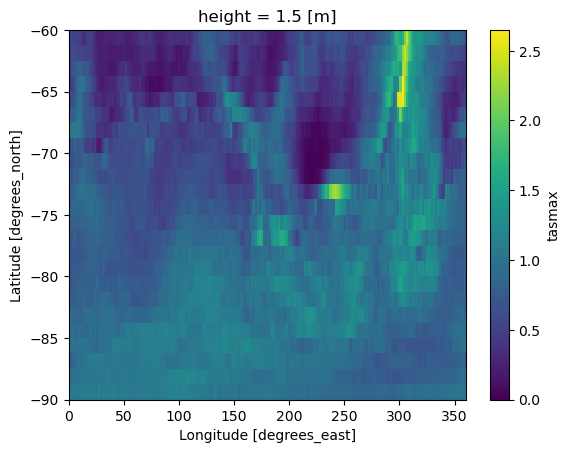

In [70]:
pr_epochs.isel(time=-1).plot()

# Percentiles - draft array

In [33]:
# hist_nat_da = xr.open_mfdataset(hist_nat_path)
# hist_nat_da.tasmax

In [34]:
# hist_da.tasmax.encoding['chunksizes']

In [31]:
#hist_da = xr.open_dataset(hist_path)

In [26]:
import matplotlib.pyplot as plt

In [27]:
loc = dict(lat=-62, lon=57, method='nearest')

In [193]:
arr = hist_da.tasmax.sel(**loc).values

In [194]:
arr_nat = hist_nat_da.tasmax.sel(**loc).values

In [195]:
hist_nat_time = hist_nat_da.time.values
hist_time = hist_da.time.values

In [196]:
hist_nat_da

<xarray.Dataset> Size: 4GB
Dimensions:    (time: 36000, bnds: 2, lat: 144, lon: 192)
Coordinates:
  * time       (time) object 288kB 1850-01-01 12:00:00 ... 1949-12-30 12:00:00
  * lat        (lat) float64 1kB -89.38 -88.12 -86.88 ... 86.88 88.12 89.38
  * lon        (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
    height     float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 576kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    lat_bnds   (lat, bnds) float64 2kB dask.array<chunksize=(144, 2), meta=np.ndarray>
    lon_bnds   (lon, bnds) float64 3kB dask.array<chunksize=(192, 2), meta=np.ndarray>
    tasmax     (time, lat, lon) float32 4GB dask.array<chunksize=(1, 144, 192), meta=np.ndarray>
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            DAMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  154800.0
    creation_date:          2021-12-21T14:13:06Z
    ...                     ...
    tracking_id:            hdl:21.14100/3e826075-70b4-4f00-a72f-e79b63e042a0
    variable_id:            tasmax
    variable_name:          tasmax
    variant_label:          r10i1p1f3
    license:                CMIP6 model data produced by the Met Office Hadle...
    cmor_version:           3.6.1

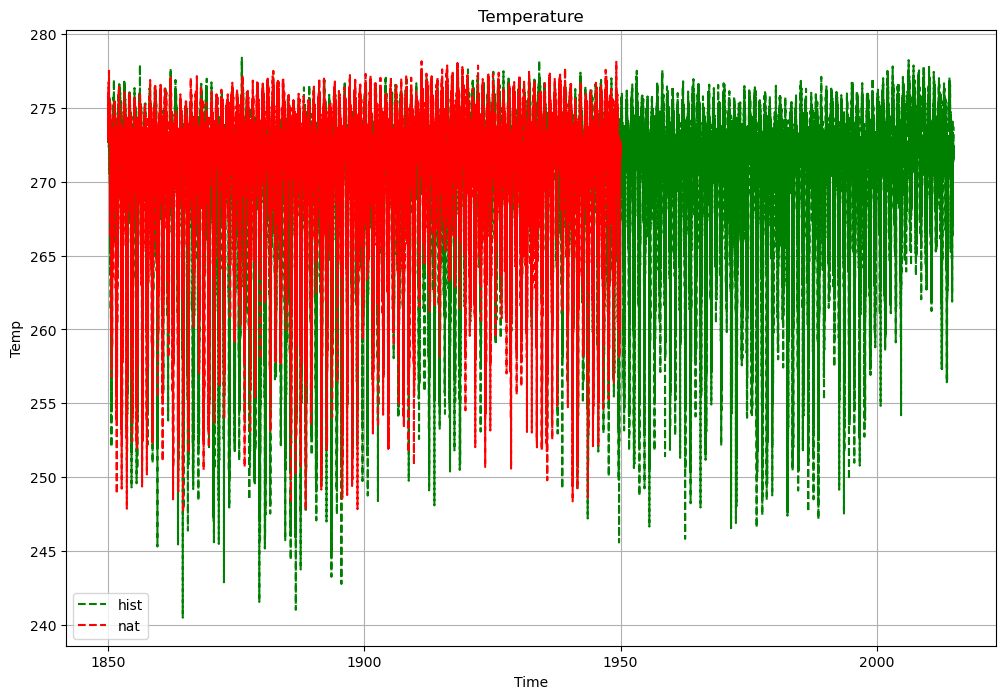

In [197]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111)
ax.plot(hist_time, arr, linestyle='--', color='green', label='hist')
ax.plot(hist_nat_time, arr_nat, linestyle='--', color='red', label='nat')

ax.set_ylabel('Temp')
ax.set_xlabel('Time')
ax.grid()
ax.set_title('Temperature')
ax.legend()


In [199]:
def exceedances(sorted_vals, threshold, n_valid=None):
    """Values strictly above a threshold, from pre-sorted data.

    sorted_vals: sorted ascending, NaNs at the end.
    threshold: exceedances are strictly greater than this.
    n_valid: number of non-NaN values. If None, uses the whole array.
    """
    if n_valid is None:
        n_valid = len(sorted_vals)

    # Binary search for first index above threshold. Slicing to n_valid
    # excludes NaNs, which sort as greater than everything.
    start = np.searchsorted(sorted_vals[:n_valid], threshold, side='right')
    return sorted_vals[start:n_valid]

In [200]:
def threshold_exceedances_sorted(sorted_vals, threshold, n_valid=None):
    """Values strictly above a threshold, from pre-sorted data.

    sorted_vals: sorted ascending, NaNs at the end.
    threshold: exceedances are strictly greater than this.
    n_valid: number of non-NaN values. If None, uses the whole array.
    """
    if n_valid is None:
        n_valid = len(sorted_vals)

    # Binary search for first index above threshold. Slicing to n_valid
    # excludes NaNs, which sort as greater than everything.
    start = np.searchsorted(sorted_vals[:n_valid], threshold, side='right')
    return sorted_vals[start:n_valid]

# Probability Ratio

$PR = \dfrac{P_{hist}}{P_{hist nat}}$

In [201]:
q = 99

In [202]:
arr_sorted = np.sort(arr)
arr_nat_sorted = np.sort(arr_nat)

In [203]:
arr_counts = len(arr_sorted)

In [204]:
nat_q_float = sorted_percentile(arr_nat_sorted, q)
nat_q_float

np.float32(276.3362)

In [205]:
hist_q_exceedances = threshold_exceedances_sorted(arr_sorted, nat_q_float)

In [206]:
len(hist_q_exceedances)/len(arr_sorted)

0.005303030303030303

In [207]:
window = 30 * 365
window_counts = []
for i in range(len(arr_sorted)-window):
    sub_arr = arr[i:i+window]
    counts = np.count_nonzero(sub_arr > nat_q_float)
    window_counts.append(counts)

window_counts = np.array(window_counts)

In [208]:
p_hist = window_counts/window
p_hist

array([0.00255708, 0.00255708, 0.00255708, ..., 0.01214612, 0.01214612,
       0.01214612], shape=(48450,))

In [209]:
p_nat = (100 - q)/100

In [210]:
pr_arr = p_hist/p_nat

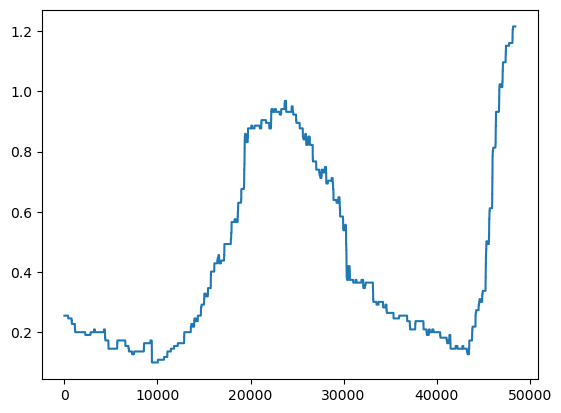

In [211]:
plt.plot(pr_arr)

In [212]:
len(pr_arr)

48450

In [236]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as mticker

Text(0.5, 0.96, "Probability ratio at {'lat': -62, 'lon': 57, 'method': 'nearest'}")

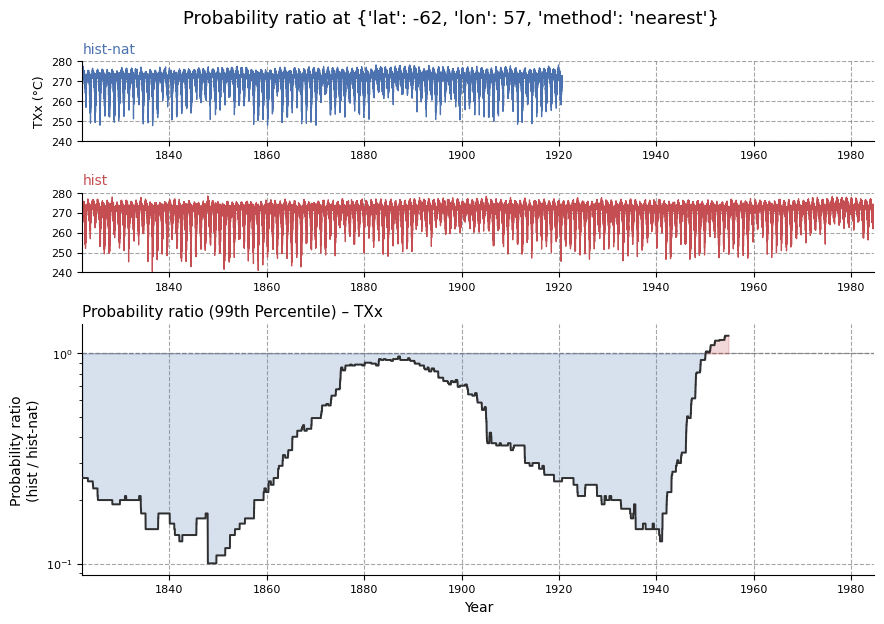

In [240]:


C_NAT, C_HIST, C_PR = "#4C72B0", "#C44E52", "#2F2F2F"

t = np.asarray(hist_time)
xlim = (t.min(), t.max())

fig = plt.figure(figsize=(9, 6.5))
gs = GridSpec(3, 1, figure=fig, height_ratios=[0.7, 0.7, 2.2],
              hspace=0.38, left=0.09, right=0.97, top=0.88, bottom=0.09)

ax_nat  = fig.add_subplot(gs[0])
ax_hist = fig.add_subplot(gs[1])
ax_pr   = fig.add_subplot(gs[2])

ax_nat.plot(hist_nat_time, arr_nat, lw=0.9, color=C_NAT)
ax_nat.set_title("hist-nat", fontsize=10, loc="left", color=C_NAT)
ax_nat.set_ylabel("TXx (°C)", fontsize=9)

ax_hist.plot(hist_time, arr, lw=0.9, color=C_HIST)
ax_hist.set_title("hist", fontsize=10, loc="left", color=C_HIST)

ax_pr.axhline(1.0, color="0.55", lw=0.9, ls="--", zorder=1)
pr_time = hist_time[:len(pr_arr)]
ax_pr.plot(pr_time, pr_arr, lw=1.4, color=C_PR, zorder=3)
ax_pr.fill_between(pr_time, 1.0, pr_arr, where=np.asarray(pr_arr) >= 1.0,
                   color=C_HIST, alpha=0.22, interpolate=True, zorder=2)
ax_pr.fill_between(pr_time, 1.0, pr_arr, where=np.asarray(pr_arr) < 1.0,
                   color=C_NAT, alpha=0.22, interpolate=True, zorder=2)
ax_pr.set_yscale("log")
ax_pr.set_ylabel("Probability ratio\n(hist / hist-nat)", fontsize=10)
ax_pr.set_xlabel("Year", fontsize=10)
ax_pr.set_title(f"Probability ratio ({q}th Percentile) – TXx", fontsize=11, loc="left")

for ax in (ax_nat, ax_hist):
    ax.set_ylim(240, 280)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(10))
for ax in (ax_nat, ax_hist, ax_pr):
    ax.set_xlim(xlim)
    ax.grid(True, linestyle='--', alpha=0.7, color='grey')
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8)
    # if np.issubdtype(t.dtype, np.datetime64):
    ax.xaxis.set_major_locator(mdates.YearLocator(20))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        

fig.suptitle(f"Probability ratio at {loc}", fontsize=13, y=0.96)